In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
caco2_train = pd.read_csv('features/Descriptors/Train_2d_3d_all_descriptors_Caco2.csv')
caco2_test = pd.read_csv('features/Descriptors/Test_2d_3d_all_descriptors_Caco2.csv')
caco2_df = pd.concat([caco2_train, caco2_test], axis=0, ignore_index=True)
caco2_df

/tmp/ipykernel_992694/3913340325.py:1: DtypeWarning: Columns (1275,1277,1280,1285,1298,1354,1356,1359,1364,1377,1579,1580,1581,1583,1584,1596,1597) have mixed types. Specify dtype option on import or set low_memory=False.
  caco2_train = pd.read_csv('features/Descriptors/Train_2d_3d_all_descriptors_Caco2.csv')


,ID,SMILES,Permeability,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,P1s,P2s,E1s,E2s,E3s,Ts,As,Vs,Ks,Ds
0,2064,CC[C@H](C)[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C)C(=...,-7.19,15.976055,15.976055,0.030813,-1.935404,0.058779,22.883333,1664.156,...,0.682480,0.263316,0.443174,0.407327,0.382690,86.049198,1710.236099,8002.655598,0.523721,1.233191
1,2067,CC[C@H](C)[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C)C(=...,-7.24,16.083777,16.083777,0.027668,-1.934865,0.053531,23.411765,1650.129,...,0.649321,0.261240,0.473762,0.435183,0.424702,75.043451,1413.897215,7900.542155,0.473981,1.333648
2,1914,CCCCN1CC(=O)N(C)[C@@H](CC(C)C)C(=O)N[C@@H](CCC...,-8.00,15.668220,15.668220,0.003714,-4.150777,0.085546,24.018349,1587.863,...,0.453945,0.442816,0.519102,0.558050,0.307857,61.920501,1125.686310,6114.512304,0.345141,1.385010
3,2026,CC[C@H](C)[C@@H]1NC(=O)[C@H](CC(C)C)N(C)C(=O)[...,-5.64,16.048909,16.048909,0.025704,-1.891709,0.101375,24.159292,1574.031,...,0.684172,0.255207,0.455347,0.407037,0.345978,81.472355,1536.980018,7342.617572,0.526258,1.208362
4,1920,CCCCN1CC(=O)N(C)[C@@H](Cc2cccc(Cl)c2)C(=O)N[C@...,-7.05,15.511700,15.511700,0.033138,-4.150544,0.085338,23.366972,1567.445,...,0.602089,0.313243,0.519864,0.540548,0.332260,66.912273,1191.395466,6042.190896,0.403133,1.392672
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1254,2485,CC(C)C[C@H]1NC(=O)[C@H](C)NC(=O)[C@@H](Cc2cccc...,-6.00,12.958074,12.958074,0.156212,-0.733388,0.586385,24.903226,430.593,...,0.596354,0.355038,0.532925,0.525713,0.444230,21.235527,116.332557,236.122220,0.427088,1.502868
1255,2489,CC(C)CN1CC(=O)NCCCCCCN[C@@H](Cc2ccccc2)C(=O)N[...,-3.99,13.040403,13.040403,0.016783,-0.701825,0.680196,22.838710,430.593,...,0.666921,0.279758,0.442211,0.464638,0.469105,21.677207,111.392008,234.404547,0.500382,1.375955
1256,2478,CC(C)C[C@@H]1NC(=O)[C@H](C)NCCCCCCNC(=O)[C@H](...,-5.24,13.114656,13.114656,0.186152,-0.689890,0.586385,24.903226,430.593,...,0.585075,0.342986,0.454788,0.501705,0.443123,20.730176,114.928147,264.264648,0.392091,1.399616
1257,2479,CC(C)C[C@@H]1NCCCCCCNC(=O)[C@H](C)NC(=O)[C@H](...,-4.77,13.101637,13.101637,0.172241,-0.755076,0.586385,24.903226,430.593,...,0.570406,0.368369,0.477650,0.533995,0.392357,21.516702,123.888733,273.556994,0.408162,1.404002


In [3]:
df_num = caco2_df.drop(columns=["ID", "SMILES"], errors="ignore")
df_num = df_num.select_dtypes(include=["number"])

#correlation with permeability
corr = df_num.corr()["Permeability"].drop("Permeability")

# Top 5 positively correlated features
top_pos = corr.sort_values(ascending=False).head(5)

# Top 5 negatively correlated features
top_neg = corr.sort_values(ascending=True).head(5)

result_df_caco2 = pd.concat([top_pos, top_neg]).reset_index()
result_df_caco2.columns = ["Feature", "Caco-2"]

print(result_df_caco2)


              Feature    Caco-2
0  AtomTypeEState.252  0.528439
1              ATSC4c  0.506272
2              ATSC.4  0.503990
3             mindssC  0.495811
4             minwHBa  0.495811
5               TDB9s -0.525253
6               TDB9m -0.502865
7              TPSA_x -0.502476
8           TopoPSA_x -0.502476
9           TopoPSA.1 -0.501528


In [4]:
print(result_df_caco2['Feature'].to_list())

['AtomTypeEState.252', 'ATSC4c', 'ATSC.4', 'mindssC', 'minwHBa', 'TDB9s', 'TDB9m', 'TPSA_x', 'TopoPSA_x', 'TopoPSA.1']


In [5]:
pampa_train = pd.read_csv('/home/users/akshay/PCPpred/PAMPA/features/Descriptors/Train_2d_3d_all_descriptors.csv')
pampa_test = pd.read_csv('/home/users/akshay/PCPpred/PAMPA/features/Descriptors/Test_2d_3d_all_descriptors.csv')
pampa_df = pd.concat([pampa_train, pampa_test], axis=0, ignore_index=True)
pampa_df

/tmp/ipykernel_992694/2227597105.py:1: DtypeWarning: Columns (1275,1277,1280,1285,1292,1298,1304,1354,1356,1359,1364,1371,1377,1383,1579,1580,1581,1583,1584,1590,1595,1596,1597) have mixed types. Specify dtype option on import or set low_memory=False.
  pampa_train = pd.read_csv('/home/users/akshay/PCPpred/PAMPA/features/Descriptors/Train_2d_3d_all_descriptors.csv')
/tmp/ipykernel_992694/2227597105.py:2: DtypeWarning: Columns (1275,1277,1292,1298,1354,1356,1371,1377,1579,1580,1581,1583,1584,1595,1596,1597) have mixed types. Specify dtype option on import or set low_memory=False.
  pampa_test = pd.read_csv('/home/users/akshay/PCPpred/PAMPA/features/Descriptors/Test_2d_3d_all_descriptors.csv')


,ID,SMILES,Permeability,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,P1s,P2s,E1s,E2s,E3s,Ts,As,Vs,Ks,Ds
0,915,CC[C@H](C)[C@H](NC(=O)[C@@H]1CC(=O)N[C@@H](Cc2...,-7.00,15.738544,15.738544,0.010382,-1.908222,0.047997,24.622047,1773.325,...,0.645217,0.280139,0.482152,0.434807,0.328596,85.400757,1822.029585,10310.940180,0.467826,1.245555
1,888,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1cccc(Cl)c1)N(C)...,-7.00,15.975705,15.975705,0.027671,-1.943827,0.026511,21.983740,1745.057,...,0.823799,0.133805,0.505465,0.357149,0.373757,96.526908,1405.322971,5704.929467,0.735698,1.236370
2,593,C/N=C(\NC)NCCC[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C...,-7.00,15.828473,15.828473,0.049834,-1.862294,0.021075,22.464000,1733.267,...,0.638375,0.270605,0.448344,0.374973,0.359780,77.329248,1527.741116,8875.871077,0.457562,1.183097
3,916,CC[C@H](C)[C@H](NC(=O)[C@@H](NC(=O)[C@@H]1CC(=...,-7.00,15.595105,15.595105,0.004954,-1.811756,0.069603,24.479675,1725.281,...,0.565329,0.374752,0.554262,0.543760,0.297042,87.856411,2070.065223,10766.402505,0.410122,1.395064
4,900,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)N(C)C(=O...,-7.00,15.867592,15.867592,0.029192,-1.876686,0.046796,23.089431,1723.309,...,0.834311,0.113966,0.516432,0.367614,0.451429,108.294919,1690.332479,8044.745507,0.751467,1.335474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6955,2481,CC(C)C[C@H]1NC(=O)[C@H](C)NC(=O)[C@H](Cc2ccccc...,-4.50,12.958074,12.958074,0.156212,-0.733388,0.586385,24.903226,430.593,...,0.719948,0.221983,0.461292,0.478911,0.410452,21.264177,96.995284,207.488727,0.579923,1.350655
6956,2485,CC(C)C[C@H]1NC(=O)[C@H](C)NC(=O)[C@@H](Cc2cccc...,-4.80,12.958074,12.958074,0.156212,-0.733388,0.586385,24.903226,430.593,...,0.712577,0.226527,0.474584,0.463075,0.429658,22.925205,114.891434,256.251692,0.568866,1.367317
6957,5604,CC(C)CN1CC(=O)N[C@@H](Cc2ccccc2)C(=O)NCCCCC(=O...,-6.38,12.898424,12.898424,0.143657,-0.742398,0.662387,22.258065,430.549,...,0.544506,0.389352,0.501813,0.459884,0.479810,20.788934,118.318494,265.091453,0.400788,1.441507
6958,2513,C[C@H]1NCCCCCCNC(=O)[C@H](Cc2ccc(O)cc2)NC(=O)[...,-7.80,13.095577,13.095577,0.065481,-0.737917,0.561202,26.806452,430.549,...,0.554492,0.350152,0.404760,0.473007,0.444278,19.365724,105.166185,258.994679,0.356966,1.322045


In [6]:
df_pampa = pampa_df[['AtomTypeEState.252', 'ATSC4c', 'ATSC.4', 'mindssC', 'minwHBa', 'TDB9s', 'TDB9m', 'TPSA_x', 'TopoPSA_x', 'TopoPSA.1','Permeability']]

In [7]:
df_pampa

,AtomTypeEState.252,ATSC4c,ATSC.4,mindssC,minwHBa,TDB9s,TDB9m,TPSA_x,TopoPSA_x,TopoPSA.1,Permeability
0,-1.054209,-3.031659,-4.015168,-1.054209,-1.054209,21.746230,360.037218,404.43,404.43,404.43,-7.00
1,-1.083914,-2.715307,-3.616072,-1.051032,-1.051032,20.957978,381.986991,366.10,366.10,366.10,-7.00
2,-0.965002,-3.113149,-4.065817,-0.965002,-0.965002,21.464011,380.808967,382.29,382.29,382.29,-7.00
3,-1.003176,-2.639503,-3.456447,-1.003176,-1.003176,21.026527,338.295952,395.64,395.64,395.64,-7.00
4,-0.990496,-2.883453,-3.811478,-0.990496,-0.990496,20.617271,333.829641,377.62,377.62,377.62,-7.00
...,...,...,...,...,...,...,...,...,...,...,...
6955,-0.347495,-0.654194,-0.872530,-0.347495,-0.347495,15.249224,204.231914,99.33,99.33,99.33,-4.50
6956,-0.347495,-0.654194,-0.872530,-0.347495,-0.347495,16.505272,223.597781,99.33,99.33,99.33,-4.80
6957,-0.404186,-0.791766,-1.050981,-0.404186,-0.404186,19.499486,266.766820,107.61,107.61,107.61,-6.38
6958,-0.287896,-0.568500,-0.757626,-0.287896,-0.287896,18.461672,247.684411,110.77,110.77,110.77,-7.80


In [8]:
df_numeric = df_pampa.apply(pd.to_numeric, errors="coerce")
df_pampa = df_pampa[df_numeric.notna().all(axis=1)].reset_index(drop=True)
df_pampa

,AtomTypeEState.252,ATSC4c,ATSC.4,mindssC,minwHBa,TDB9s,TDB9m,TPSA_x,TopoPSA_x,TopoPSA.1,Permeability
0,-1.054209,-3.031659,-4.015168,-1.054209,-1.054209,21.746230,360.037218,404.43,404.43,404.43,-7.00
1,-1.083914,-2.715307,-3.616072,-1.051032,-1.051032,20.957978,381.986991,366.10,366.10,366.10,-7.00
2,-0.965002,-3.113149,-4.065817,-0.965002,-0.965002,21.464011,380.808967,382.29,382.29,382.29,-7.00
3,-1.003176,-2.639503,-3.456447,-1.003176,-1.003176,21.026527,338.295952,395.64,395.64,395.64,-7.00
4,-0.990496,-2.883453,-3.811478,-0.990496,-0.990496,20.617271,333.829641,377.62,377.62,377.62,-7.00
...,...,...,...,...,...,...,...,...,...,...,...
6955,-0.347495,-0.654194,-0.872530,-0.347495,-0.347495,15.249224,204.231914,99.33,99.33,99.33,-4.50
6956,-0.347495,-0.654194,-0.872530,-0.347495,-0.347495,16.505272,223.597781,99.33,99.33,99.33,-4.80
6957,-0.404186,-0.791766,-1.050981,-0.404186,-0.404186,19.499486,266.766820,107.61,107.61,107.61,-6.38
6958,-0.287896,-0.568500,-0.757626,-0.287896,-0.287896,18.461672,247.684411,110.77,110.77,110.77,-7.80


In [9]:
corr = df_pampa.corr()["Permeability"].drop("Permeability")
corr

AtomTypeEState.252   -0.061721
ATSC4c               -0.005851
ATSC.4                0.013412
mindssC              -0.073527
minwHBa              -0.073527
TDB9s                 0.004229
TDB9m                 0.011175
TPSA_x                0.061666
TopoPSA_x             0.061666
TopoPSA.1             0.048999
Name: Permeability, dtype: float64

In [10]:
corr_pampa = corr.reset_index()
corr_pampa.columns = ["Feature", "PAMPA"]

print(corr_pampa)

              Feature     PAMPA
0  AtomTypeEState.252 -0.061721
1              ATSC4c -0.005851
2              ATSC.4  0.013412
3             mindssC -0.073527
4             minwHBa -0.073527
5               TDB9s  0.004229
6               TDB9m  0.011175
7              TPSA_x  0.061666
8           TopoPSA_x  0.061666
9           TopoPSA.1  0.048999


In [11]:
rrck_train = pd.read_csv('/home/users/akshay/PCPpred/RRCK/features/Descriptors/Train_2d_3d_all_descriptors_RRCK.csv')
rrck_test = pd.read_csv('/home/users/akshay/PCPpred/RRCK/features/Descriptors/Test_2d_3d_all_descriptors_RRCK.csv')
rrck_df = pd.concat([rrck_train, rrck_test], axis=0, ignore_index=True)
rrck_df

,ID,SMILES,Permeability,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,P1s,P2s,E1s,E2s,E3s,Ts,As,Vs,Ks,Ds
0,2358,C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](C(...,-6.13,15.193873,15.193873,0.130769,-1.621791,0.147476,26.802326,1216.662,...,0.555662,0.361731,0.544173,0.495228,0.417788,55.253242,844.996910,3701.072059,0.376090,1.457189
1,2359,C/C=C/C[C@@H](C)C(=O)[C@H]1C(=O)N[C@@H](C(C)C)...,-6.66,15.152762,15.152762,0.128114,-1.816236,0.134993,26.372093,1214.646,...,0.514250,0.383940,0.446697,0.436831,0.348132,50.660858,741.432722,3405.746601,0.347284,1.231660
2,5669,C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC...,-5.76,15.129540,15.129540,0.022871,-1.609940,0.147925,26.905882,1202.635,...,0.584567,0.352614,0.534974,0.490552,0.346062,57.530851,877.093731,3400.242320,0.405772,1.371588
3,2360,C/C=C/C[C@@H](C)[C@H]1OC(=O)[C@H](C(C)C)N(C)C(...,-6.78,15.028142,15.028142,0.097424,-1.231351,0.116062,27.411765,1202.635,...,0.540927,0.396766,0.520911,0.514156,0.415753,54.389916,807.742283,3013.737615,0.406540,1.450820
4,2353,C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](C)...,-5.87,15.068092,15.068092,0.128760,-1.611421,0.157205,27.083333,1188.608,...,0.572679,0.345721,0.523047,0.544280,0.438872,53.667187,786.079599,3336.947160,0.377600,1.506199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,2366,CC(C)C[C@@H]1NC(=O)[C@H](CC(C)C)N(C)C(=O)[C@H]...,-4.57,14.375946,14.375946,0.041143,-0.968617,0.426120,27.588235,708.945,...,0.564952,0.353375,0.478433,0.526592,0.368063,31.026437,264.381646,782.398645,0.377491,1.373088
171,2338,CC(C)C[C@@H]1NC(=O)[C@H](Cc2ccccc2)NC(=O)[C@H]...,-5.06,14.149007,14.149007,0.013343,-1.040266,0.252518,26.280000,696.934,...,0.537906,0.367610,0.556893,0.533052,0.453758,30.892042,270.354819,852.042735,0.358274,1.543702
172,2310,CC[C@H]1C(=O)N[C@@H](CC(C)C)C(=O)N2CCC[C@@H]2C...,-4.49,14.285259,14.285259,0.023988,-0.981187,0.432506,27.000000,682.907,...,0.524532,0.371803,0.421158,0.378566,0.417063,27.788434,222.347286,683.954881,0.344503,1.216787
173,2309,CC(C)C[C@@H]1NC(=O)[C@H](C)N(C)C(=O)[C@H]2CCCN...,-4.60,14.310395,14.310395,0.043619,-0.929433,0.409958,28.000000,662.917,...,0.440685,0.368620,0.491679,0.431117,0.322097,25.186924,200.956467,721.104596,0.213958,1.244894


In [12]:
df_rrck = rrck_df[['AtomTypeEState.252', 'ATSC4c', 'ATSC.4', 'mindssC', 'minwHBa', 'TDB9s', 'TDB9m', 'TPSA_x', 'TopoPSA_x', 'TopoPSA.1','Permeability']]

In [13]:
df_rrck

,AtomTypeEState.252,ATSC4c,ATSC.4,mindssC,minwHBa,TDB9s,TDB9m,TPSA_x,TopoPSA_x,TopoPSA.1,Permeability
0,-0.880867,-2.040847,-2.766621,-0.880867,-0.880867,19.774566,306.240745,278.80,278.80,278.80,-6.13
1,-0.980404,-2.046370,-2.754776,-0.980404,-0.980404,20.423504,311.679239,275.64,275.64,275.64,-6.66
2,-0.877950,-2.061569,-2.786067,-0.877950,-0.877950,20.160277,310.139157,278.80,278.80,278.80,-5.76
3,-0.817058,-1.969546,-2.563900,-0.817058,-0.817058,20.064347,290.782667,276.59,276.59,276.59,-6.78
4,-0.895867,-2.076990,-2.800238,-0.895867,-0.895867,20.151275,304.040192,278.80,278.80,278.80,-5.87
...,...,...,...,...,...,...,...,...,...,...,...
170,-0.465899,-1.103497,-1.484686,-0.465899,-0.465899,18.970391,325.057862,139.44,139.44,139.44,-4.57
171,-0.535371,-1.447605,-1.964999,-0.535371,-0.535371,19.691377,314.524282,165.81,165.81,165.81,-5.06
172,-0.489277,-1.148331,-1.542493,-0.489277,-0.489277,18.733617,306.408809,139.44,139.44,139.44,-4.49
173,-0.489779,-1.136954,-1.518708,-0.489779,-0.489779,18.096558,281.742005,139.44,139.44,139.44,-4.60


In [14]:
df_numeric = df_rrck.apply(pd.to_numeric, errors="coerce")
df_rrck = df_rrck[df_numeric.notna().all(axis=1)].reset_index(drop=True)

In [15]:
corr = df_rrck.corr()["Permeability"].drop("Permeability")
corr

AtomTypeEState.252    0.347233
ATSC4c                0.394656
ATSC.4                0.385154
mindssC               0.319061
minwHBa               0.319061
TDB9s                -0.169090
TDB9m                -0.244270
TPSA_x               -0.492353
TopoPSA_x            -0.492353
TopoPSA.1            -0.464168
Name: Permeability, dtype: float64

In [16]:
corr_rrck = corr.reset_index()
corr_rrck.columns = ["Feature", "RRCK"]

print(corr_rrck)

              Feature      RRCK
0  AtomTypeEState.252  0.347233
1              ATSC4c  0.394656
2              ATSC.4  0.385154
3             mindssC  0.319061
4             minwHBa  0.319061
5               TDB9s -0.169090
6               TDB9m -0.244270
7              TPSA_x -0.492353
8           TopoPSA_x -0.492353
9           TopoPSA.1 -0.464168


In [17]:
mdck_train = pd.read_csv('/home/users/akshay/PCPpred/MDCK/features/Descriptors/Train_2d_3d_all_descriptors_MDCK.csv')
mdck_test = pd.read_csv('/home/users/akshay/PCPpred/MDCK/features/Descriptors/Test_2d_3d_all_descriptors_MDCK.csv')
mdck_df = pd.concat([mdck_train, mdck_test], axis=0, ignore_index=True)
mdck_df

,ID,SMILES,Permeability,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,P1s,P2s,E1s,E2s,E3s,Ts,As,Vs,Ks,Ds
0,1114,CC(C)C[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C)C(=O)[C...,-4.940000,14.922930,14.922930,0.059501,-1.162678,0.238950,27.097561,1139.494,...,0.490993,0.446412,0.502821,0.521474,0.367154,50.115915,697.880017,2474.945996,0.406107,1.391449
1,1113,CC(C)C[C@@H]1NC(=O)[C@@H]2CCCN2C(=O)[C@@H](Cc2...,-5.820000,15.128047,15.128047,0.075261,-1.145488,0.238950,27.097561,1139.494,...,0.530772,0.398556,0.543790,0.527114,0.372276,47.613373,628.467138,2289.825818,0.393991,1.443180
2,1117,CC(C)C[C@@H]1NC(=O)[C@H](C)N(C)C(=O)[C@H]2CCCN...,-5.650000,14.908525,14.908525,0.051146,-1.177248,0.238950,27.097561,1139.494,...,0.527383,0.387331,0.523372,0.543333,0.399556,48.105086,653.233321,2640.699755,0.372071,1.466261
3,1119,CC(C)C[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C)C(=O)[C...,-6.250000,14.724823,14.724823,0.030635,-1.196597,0.240803,26.125000,1115.472,...,0.528976,0.349388,0.516241,0.483660,0.323140,49.516594,715.115788,3493.983049,0.317545,1.323041
4,2428,CCN1CC(=O)N[C@@H](CC(C)C)C(=O)N(C)[C@@H](C)C(=...,-5.510000,14.918925,14.918925,0.008728,-1.166833,0.250056,27.358974,1091.406,...,0.506249,0.395804,0.498185,0.483571,0.313967,46.999494,637.788214,2722.371988,0.353079,1.295723
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,8345,CCOC(=O)[C@@H]1CSCC(=O)N[C@@H](CC)C(=O)N(CC(C)...,-7.534591,14.235704,14.235704,0.008614,-1.181469,0.216153,26.159420,996.327,...,0.532833,0.379510,0.478903,0.524793,0.340577,45.177438,575.947872,2255.562804,0.368514,1.344273
60,6423,CC(=O)N1CCC[C@@H]1C(=O)N(C)[C@@H](CC(C)C)C(=O)...,-6.300000,14.765338,14.765338,0.082043,-1.652577,0.137104,27.528571,988.282,...,0.616065,0.311878,0.435148,0.417772,0.254081,49.869778,644.135872,2411.114189,0.424098,1.107002
61,1108,CC(C)C[C@@H]1NC(=O)[C@H](C)N(C)C(=O)[C@@H](C)N...,-5.180000,14.121032,14.121032,0.089106,-1.124048,0.271385,28.764706,963.276,...,0.576263,0.369142,0.519954,0.531563,0.333557,46.528470,572.262997,1788.618525,0.418108,1.385074
62,1843,CC[C@H](C)[C@@H]1NC(=O)[C@@H](CC(C)C)NC(=O)[C@...,-4.400000,14.424770,14.424770,0.002738,-1.061047,0.252294,25.773585,730.951,...,0.474145,0.403049,0.448745,0.502249,0.335460,28.929964,250.102493,847.276168,0.315790,1.286454


In [18]:
df_mdck = mdck_df[['AtomTypeEState.252', 'ATSC4c', 'ATSC.4', 'mindssC', 'minwHBa', 'TDB9s', 'TDB9m', 'TPSA_x', 'TopoPSA_x', 'TopoPSA.1','Permeability']]

In [19]:
df_mdck

,AtomTypeEState.252,ATSC4c,ATSC.4,mindssC,minwHBa,TDB9s,TDB9m,TPSA_x,TopoPSA_x,TopoPSA.1,Permeability
0,-0.632770,-2.029142,-2.706832,-0.632770,-0.632770,20.165511,352.560187,238.26,238.26,238.26,-4.940000
1,-0.642430,-2.035868,-2.714206,-0.642430,-0.642430,19.526753,328.722315,238.26,238.26,238.26,-5.820000
2,-0.635680,-2.029362,-2.707036,-0.635680,-0.635680,19.978232,352.040279,238.26,238.26,238.26,-5.650000
3,-0.667681,-2.147024,-2.824692,-0.667681,-0.667681,20.999113,351.524313,238.26,238.26,238.26,-6.250000
4,-0.645388,-2.056371,-2.763984,-0.645388,-0.645388,20.536809,360.893803,247.49,247.49,247.49,-5.510000
...,...,...,...,...,...,...,...,...,...,...,...
59,-0.730191,-1.911484,-2.557568,-0.656117,-0.656117,20.878301,356.693902,244.25,244.25,269.55,-7.534591
60,-0.903584,-1.974855,-2.694890,-0.903584,-0.903584,22.091752,339.737185,261.83,261.83,261.83,-6.300000
61,-0.658950,-2.177338,-2.883540,-0.658950,-0.658950,20.239398,309.648274,238.26,238.26,238.26,-5.180000
62,-0.545602,-1.480237,-2.005896,-0.545602,-0.545602,19.361053,322.510241,165.81,165.81,165.81,-4.400000


In [20]:
df_numeric = df_mdck.apply(pd.to_numeric, errors="coerce")
df_mdck = df_mdck[df_numeric.notna().all(axis=1)].reset_index(drop=True)

In [21]:
corr = df_mdck.corr()["Permeability"].drop("Permeability")
corr

AtomTypeEState.252    0.324186
ATSC4c                0.429059
ATSC.4                0.436138
mindssC               0.230926
minwHBa               0.230926
TDB9s                -0.273793
TDB9m                -0.501942
TPSA_x               -0.502377
TopoPSA_x            -0.502377
TopoPSA.1            -0.515324
Name: Permeability, dtype: float64

In [22]:
corr_mdck = corr.reset_index()
corr_mdck.columns = ["Feature", "MDCK"]

print(corr_mdck)

              Feature      MDCK
0  AtomTypeEState.252  0.324186
1              ATSC4c  0.429059
2              ATSC.4  0.436138
3             mindssC  0.230926
4             minwHBa  0.230926
5               TDB9s -0.273793
6               TDB9m -0.501942
7              TPSA_x -0.502377
8           TopoPSA_x -0.502377
9           TopoPSA.1 -0.515324


In [23]:
merged_df = result_df_caco2.merge(corr_pampa, on="Feature", how="inner").merge(corr_rrck, on="Feature", how="inner").merge(corr_mdck, on="Feature", how="inner")

In [24]:
merged_df

,Feature,Caco-2,PAMPA,RRCK,MDCK
0,AtomTypeEState.252,0.528439,-0.061721,0.347233,0.324186
1,ATSC4c,0.506272,-0.005851,0.394656,0.429059
2,ATSC.4,0.503990,0.013412,0.385154,0.436138
3,mindssC,0.495811,-0.073527,0.319061,0.230926
4,minwHBa,0.495811,-0.073527,0.319061,0.230926
5,TDB9s,-0.525253,0.004229,-0.169090,-0.273793
6,TDB9m,-0.502865,0.011175,-0.244270,-0.501942
7,TPSA_x,-0.502476,0.061666,-0.492353,-0.502377
8,TopoPSA_x,-0.502476,0.061666,-0.492353,-0.502377
9,TopoPSA.1,-0.501528,0.048999,-0.464168,-0.515324


In [25]:
merged_df.to_csv('results/Dataset_analysis/Dataset_analysisdatasets_feature_corr_analysis.csv', index=False)

In [26]:
assays = ["Caco-2", "PAMPA", "RRCK", "MDCK"]
assay_corr = merged_df[assays].corr()
assay_corr.to_csv('results/Dataset_analysis/Corr_matrix.csv')
print(assay_corr)

          Caco-2     PAMPA      RRCK      MDCK
Caco-2  1.000000 -0.774774  0.961570  0.972675
PAMPA  -0.774774  1.000000 -0.811301 -0.718541
RRCK    0.961570 -0.811301  1.000000  0.979768
MDCK    0.972675 -0.718541  0.979768  1.000000


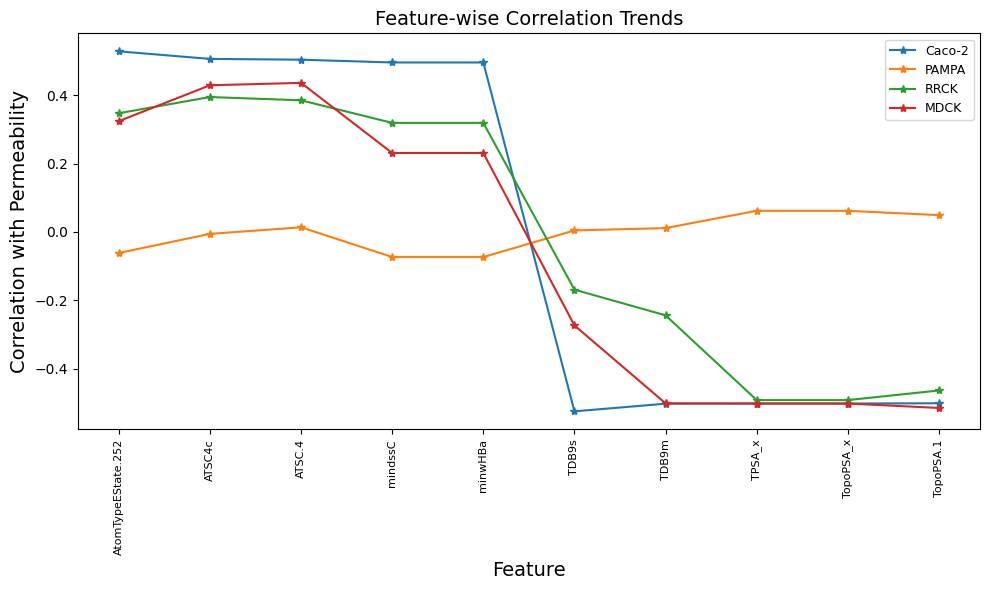

In [27]:
import matplotlib.pyplot as plt

assays = ["Caco-2", "PAMPA", "RRCK", "MDCK"]

plt.figure(figsize=(10,6))

# Line plot for assay correlations
for assay in assays:
    plt.plot(merged_df["Feature"], merged_df[assay], marker="*", label=assay)

plt.xticks(range(len(merged_df["Feature"])), merged_df["Feature"], rotation=90, fontsize=8)
plt.ylabel("Correlation with Permeability", fontsize=14)
plt.xlabel("Feature", fontsize=14)
plt.title("Feature-wise Correlation Trends", fontsize=14)
plt.legend(fontsize=9)

plt.tight_layout()
plt.savefig("results/Dataset_analysis/assay_correlation_features_lineplot.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
#datasets peptides permeability analysis

In [28]:
df_all = pd.read_csv("data/CycPeptMPDB_Peptide_All.csv")
df_all

/tmp/ipykernel_300187/673606827.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv("data/CycPeptMPDB_Peptide_All.csv")


,ID,Source,Year,Version,Original_Name_in_Source_Literature,Structurally_Unique_ID,Same_Peptides_ID,Same_Peptides_Source,Same_Peptides_Permeability,Same_Peptides_Assay,...,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,PC1,PC2,CHCl3_3DPSA,H2O_3DPSA
0,1,2006_Rezai_1,2006,1.0,Cyclosporine A,1,"[22, 932, 981, 1822, 1862, 2356, 7188, 7353]","['2011_White', '2015_Ahlbach', '2015_Bockus_1'...","[['-5.96'], ['-5.01'], ['-5.96'], ['-6.20'], [...","[['RRCK'], ['PAMPA'], ['RRCK'], ['PAMPA'], ['R...",...,0,0,0,0,0,0,-6.620416,-0.186784,174.0,173.0
1,2,2006_Rezai_1,2006,1.0,compound.1,2,[1048],['2015_Wang'],"[['-5.46', '-4.92']]","[['PAMPA', 'Caco2']]",...,0,0,0,0,0,0,2.443604,-1.286947,163.0,165.0
2,3,2006_Rezai_1,2006,1.0,compound.2,3,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,2.443604,-1.286947,163.0,162.0
3,4,2006_Rezai_1,2006,1.0,compound.3,4,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,2.443604,-1.286947,146.0,142.0
4,5,2006_Rezai_1,2006,1.0,compound.4,5,[1045],['2015_Wang'],"[['-5.79', '-5.84']]","[['PAMPA', 'Caco2']]",...,0,0,0,0,0,0,2.443604,-1.286947,164.0,165.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8461,8462,2024_Otani,2024,1.2,5a,8462,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,4.460399,4.850663,NaN,NaN
8462,8463,2024_Otani,2024,1.2,5b,8463,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,4.912179,1.994017,NaN,NaN
8463,8464,2024_Otani,2024,1.2,6a,8464,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,8.903908,6.908094,NaN,NaN
8464,8465,2024_Otani,2024,1.2,7a,8465,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,1.740731,5.279604,NaN,NaN


In [29]:
cols = ["SMILES", "PAMPA", "Caco2", "RRCK", "MDCK"]
df_selected = df_all[cols].copy()

assays = ["PAMPA", "Caco2", "RRCK", "MDCK"]
df_selected["non_null_count"] = df_selected[assays].notna().sum(axis=1)

if df_selected["non_null_count"].max() >= 3:
    df_sorted = df_selected.sort_values(
        by="non_null_count", ascending=False
    ).drop(columns="non_null_count").reset_index(drop=True)

else:
    def combo_priority(row):
        filled = tuple(sorted([a for a in assays if pd.notna(row[a])]))
        if filled == ("Caco2", "PAMPA"):
            return 1
        elif filled == ("PAMPA", "RRCK"):
            return 2
        elif filled == ("MDCK", "PAMPA"):
            return 3
        else:
            return 99  

    df_selected["priority"] = df_selected.apply(combo_priority, axis=1)

    df_sorted = df_selected.sort_values(
        by=["non_null_count", "priority"], ascending=[False, True]
    ).drop(columns=["non_null_count", "priority"]).reset_index(drop=True)

print(df_sorted)


                                                 SMILES      PAMPA  Caco2  \
0     CC[C@H](C)[C@@H]1NC(=O)[C@@H]2CCCN2C(=O)[C@H](...  -5.280000  -5.89   
1     CC[C@H](C)[C@@H]1NC(=O)[C@@H]2CCCN2C(=O)[C@H](...  -5.250000  -5.89   
2     CC[C@@H](C)[C@@H]1NC(=O)[C@@H]2CCCN2C(=O)[C@H]...  -5.280000  -6.70   
3     CC[C@H](C)[C@@H]1NC(=O)[C@@H]2CCCN2C(=O)[C@H](...  -5.320000  -5.43   
4     CC[C@@H](C)[C@@H]1NC(=O)[C@@H]2CCCN2C(=O)[C@H]...  -5.310000  -6.52   
...                                                 ...        ...    ...   
8461  CC(C)C[C@@H]1NC(=O)c2cccc(c2)C(=O)N(Cc2ccccc2[...  -5.168770    NaN   
8462  CC(C)C[C@@H]1NC(=O)c2cccc(c2)C(=O)Nc2cccc(c2)C...  -5.910095    NaN   
8463  C[C@@H]1NC(=O)c2cccc(c2)C(=O)N(Cc2ccccc2[N+](=...  -7.619789    NaN   
8464  CC(C)C[C@@H]1NC(=O)CNC(=O)c2cccc(c2)C(=O)N(Cc2...  -8.000000    NaN   
8465  CC(C)C[C@@H]1NC(=O)CNC(=O)c2cccc(c2)C(=O)Nc2cc... -10.000000    NaN   

      RRCK  MDCK  
0      NaN   NaN  
1      NaN   NaN  
2      NaN   NaN  

In [30]:
df_sorted.to_csv('results/Dataset_analysis/sorted_dataset_all_perm_values.csv', index=False)

In [31]:

cols = ["SMILES", "PAMPA", "Caco2", "RRCK", "MDCK"]
df_selected = df_all[cols].copy()

assays = ["PAMPA", "Caco2", "RRCK", "MDCK"]
df_selected["non_null_count"] = df_selected[assays].notna().sum(axis=1)

priority_map = {
    # 2 assays
    ("Caco2", "PAMPA"): 1,
    ("PAMPA", "RRCK"): 2,
    ("MDCK", "PAMPA"): 3,
    ("Caco2", "RRCK"): 4,
    ("Caco2", "MDCK"): 5,
    ("MDCK", "RRCK"): 6,
    # 1 assay
    ("PAMPA",): 1,
    ("Caco2",): 2,
    ("RRCK",): 3,
    ("MDCK",): 4
}

def combo_priority(row):
    filled = tuple(sorted([a for a in assays if pd.notna(row[a])]))
    return priority_map.get(filled, 99)  

df_selected["priority"] = df_selected.apply(combo_priority, axis=1)

df_sorted = df_selected.sort_values(
    by=["non_null_count", "priority"], ascending=[False, True]
).drop(columns=["non_null_count", "priority"]).reset_index(drop=True)

print(df_sorted)


                                                 SMILES  PAMPA  Caco2  RRCK  \
0     CC[C@H](C)[C@@H]1NC(=O)[C@@H]2CCCN2C(=O)[C@H](...  -5.28  -5.89   NaN   
1     CC[C@H](C)[C@@H]1NC(=O)[C@@H]2CCCN2C(=O)[C@H](...  -5.25  -5.89   NaN   
2     CC[C@@H](C)[C@@H]1NC(=O)[C@@H]2CCCN2C(=O)[C@H]...  -5.28  -6.70   NaN   
3     CC[C@H](C)[C@@H]1NC(=O)[C@@H]2CCCN2C(=O)[C@H](...  -5.32  -5.43   NaN   
4     CC[C@@H](C)[C@@H]1NC(=O)[C@@H]2CCCN2C(=O)[C@H]...  -5.31  -6.52   NaN   
...                                                 ...    ...    ...   ...   
8461  CC[C@H](C)[C@@H]1NC(=O)[C@@H](CC(C)C)NC(=O)[C@...    NaN    NaN   NaN   
8462  CC(C)C[C@@H]1NC(=O)[C@H](CC(C)C)NC(=O)[C@@H](C...    NaN    NaN   NaN   
8463  CC(C)C[C@@H]1NC(=O)[C@H](CC(C)C)NC(=O)[C@@H](C...    NaN    NaN   NaN   
8464  CC[C@H](C)[C@@H]1NC(=O)[C@H](CC(C)C)NC(=O)[C@H...    NaN    NaN   NaN   
8465  CC[C@H](C)[C@@H]1NC(=O)[C@@H](CC(C)C)NC(=O)[C@...    NaN    NaN   NaN   

      MDCK  
0      NaN  
1      NaN  
2      NaN  

In [32]:
df_sorted.to_csv('results/Dataset_analysis/sorted_dataset_all_perm_values.csv', index=False)

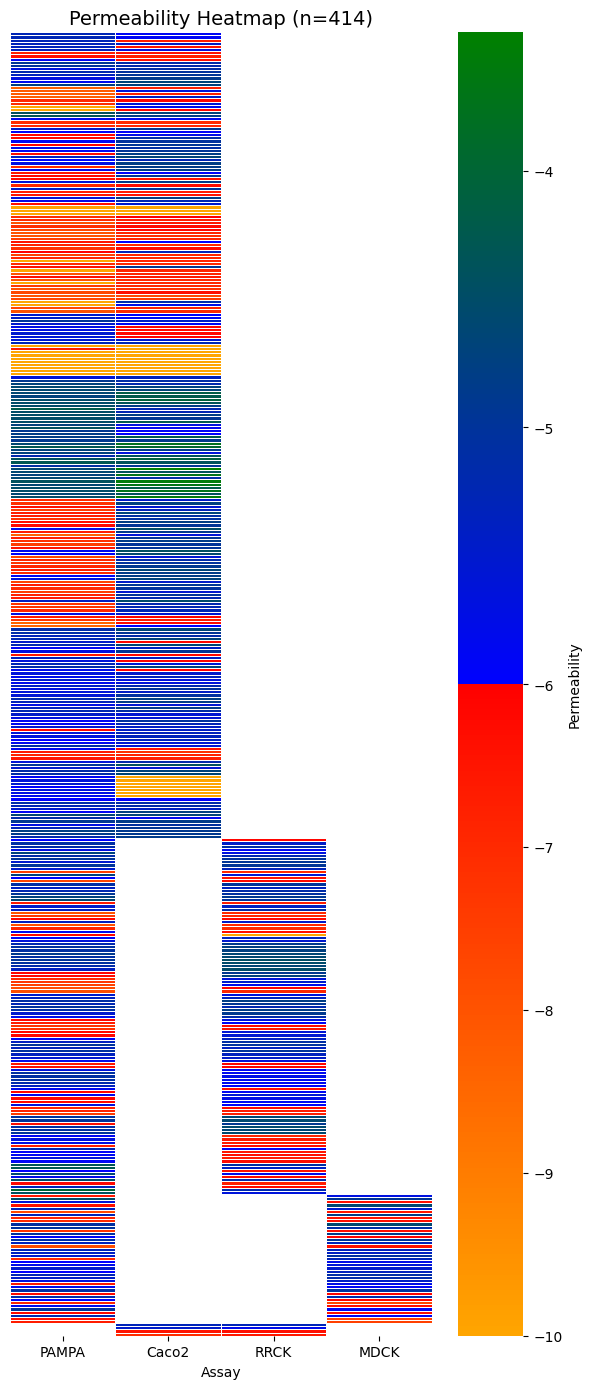

In [33]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
df = pd.read_csv("results/Dataset_analysis/sorted_dataset_all_perm_values.csv")
assays = ["PAMPA", "Caco2", "RRCK", "MDCK"]
df_dual = df[df[assays].notna().sum(axis=1) == 2].copy()

if "SMILES" in df_dual.columns:
    df_dual = df_dual.drop_duplicates(subset=["SMILES"] + assays)

vals = df_dual[assays].to_numpy(dtype=float)
data = np.ma.masked_invalid(vals)

cmap = LinearSegmentedColormap.from_list(
    "redblue_custom",
    [
        (0.0, "orange"),    
        (0.5, "red"),       
        (0.5, "blue"),      
        (1.0, "green"),     
    ],
    N=256
)

# Center colormap at -6
vmin = np.nanmin(vals)
vmax = np.nanmax(vals)
norm = TwoSlopeNorm(vmin=vmin, vcenter=-6, vmax=vmax)

plt.figure(figsize=(6, 14))
ax = sns.heatmap(
    data,
    cmap=cmap,
    norm=norm,
    annot=False,
    linewidths=0.4,
   
    cbar_kws={"label": "Permeability"},
    xticklabels=assays,
    yticklabels=False
)

ax.set_title(f"Permeability Heatmap (n={len(df_dual)})", fontsize=14)
ax.set_xlabel("Assay")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig("results/Dataset_analysis/dual_filled_heatmap_redorange_bluegreen.png", dpi=600, bbox_inches="tight")
plt.show()

In [34]:
#Performance matrix on combined four assay 2d and 3d all train and test dataset
import numpy as np
import pandas as pd
import re
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression  # LogisticRegression is not used for regression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [32]:
pampa_train = pd.read_csv("/home/users/akshay/PCPpred/PAMPA/features/Descriptors/Train_2d_3d_all_descriptors.csv")
caco2_train = pd.read_csv("/home/users/akshay/PCPpred/Caco2/features/Descriptors/Train_2d_3d_all_descriptors_Caco2.csv")
rrck_train = pd.read_csv("/home/users/akshay/PCPpred/RRCK/features/Descriptors/Train_2d_3d_all_descriptors_RRCK.csv")
mdck_train = pd.read_csv("/home/users/akshay/PCPpred/MDCK/features/Descriptors/Train_2d_3d_all_descriptors_MDCK.csv")

/tmp/ipykernel_400959/845030219.py:1: DtypeWarning: Columns (1275,1277,1280,1285,1292,1298,1304,1354,1356,1359,1364,1371,1377,1383,1579,1580,1581,1583,1584,1590,1595,1596,1597) have mixed types. Specify dtype option on import or set low_memory=False.
  pampa_train = pd.read_csv("/home/users/akshay/PCPpred/PAMPA/features/Descriptors/Train_2d_3d_all_descriptors.csv")
/tmp/ipykernel_400959/845030219.py:2: DtypeWarning: Columns (1275,1277,1280,1285,1298,1354,1356,1359,1364,1377,1579,1580,1581,1583,1584,1596,1597) have mixed types. Specify dtype option on import or set low_memory=False.
  caco2_train = pd.read_csv("/home/users/akshay/PCPpred/Caco2/features/Descriptors/Train_2d_3d_all_descriptors_Caco2.csv")


In [33]:
all_train = pd.concat([pampa_train, caco2_train, rrck_train, mdck_train], axis=0, ignore_index=True)
print(all_train.shape)

(6766, 3719)


In [34]:
pampa_test = pd.read_csv("/home/users/akshay/PCPpred/PAMPA/features/Descriptors/Test_2d_3d_all_descriptors.csv")
caco2_test = pd.read_csv("/home/users/akshay/PCPpred/Caco2/features/Descriptors/Test_2d_3d_all_descriptors_Caco2.csv")
rrck_test = pd.read_csv("/home/users/akshay/PCPpred/RRCK/features/Descriptors/Test_2d_3d_all_descriptors_RRCK.csv")
mdck_test = pd.read_csv("/home/users/akshay/PCPpred/MDCK/features/Descriptors/Test_2d_3d_all_descriptors_MDCK.csv")

/tmp/ipykernel_400959/877171020.py:1: DtypeWarning: Columns (1275,1277,1292,1298,1354,1356,1371,1377,1579,1580,1581,1583,1584,1595,1596,1597) have mixed types. Specify dtype option on import or set low_memory=False.
  pampa_test = pd.read_csv("/home/users/akshay/PCPpred/PAMPA/features/Descriptors/Test_2d_3d_all_descriptors.csv")


In [35]:
all_test = pd.concat([pampa_test, caco2_test, rrck_test, mdck_test], axis=0, ignore_index=True)
print(all_test.shape)

(1692, 3719)


In [36]:
all_train["Permeability"].max()

-3.46

In [37]:
all_test["Permeability"].max()

-3.7

In [43]:
def train_and_test_predict(models, X_train, y_train, X_test, y_test):
    kf = KFold(n_splits=5, shuffle=True, random_state=101)
    results = {}
    predictions = []  

    for model in models:
        model_name = model.__class__.__name__
        predictions_train = []
        actual_y_train = []

        test_predictions_folds = []

        for train_index, val_index in kf.split(X_train):
            X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
            y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

            model.fit(X_train_fold, y_train_fold)

            y_pred_fold = model.predict(X_val_fold)
            y_pred_fold = np.clip(y_pred_fold, -10, -3.4)
            predictions_train.extend(y_pred_fold)
            actual_y_train.extend(y_val_fold)

            predictions_test_fold = model.predict(X_test)
            predictions_test_fold = np.clip(predictions_test_fold, -10, -3.4)
            test_predictions_folds.append(predictions_test_fold)
        mse_train = mean_squared_error(actual_y_train, predictions_train)
        mae_train = mean_absolute_error(actual_y_train, predictions_train)
        rmse_train = np.sqrt(mse_train)
        r2_train = r2_score(actual_y_train, predictions_train)
        pearson_train, _ = pearsonr(actual_y_train, predictions_train)
        spearman_train, _ = spearmanr(actual_y_train, predictions_train)

        predictions_test_mean = np.mean(test_predictions_folds, axis=0)
        predictions_test_std = np.std(test_predictions_folds, axis=0)

        mse_test = mean_squared_error(y_test, predictions_test_mean)
        mae_test = mean_absolute_error(y_test, predictions_test_mean)
        rmse_test = np.sqrt(mse_test)
        r2_test = r2_score(y_test, predictions_test_mean)
        print(r2_test)
        pearson_test, _ = pearsonr(y_test, predictions_test_mean)
        spearman_test, _ = spearmanr(y_test, predictions_test_mean)

        predictions.append({
            'Model': model_name,
            'Y Train pred': predictions_train,
            'Y Test actual': y_test,
            'Test prediction folds': test_predictions_folds,
            'Test Predictions Mean': predictions_test_mean,
            'Test Predictions Std': predictions_test_std,

        })

        results[model_name] = {
            'Train MSE (5 fold cv)': f"{mse_train:.4f}",
            'Train MAE (5 fold cv)': f"{mae_train:.4f}",
            'Train RMSE (5 fold cv)': f"{rmse_train:.4f}",
            'Train RMSE (5 fold cv)': f"{rmse_train:.4f}",
            'Train R2 (5 fold cv)': f"{r2_train:.4f}",
            'Train PCC (5 fold cv)': f"{pearson_train:.4f}",
            'Train SCC (5 fold cv)': f"{spearman_train:.4f}",
            'Test MSE': f"{mse_test:.4f}",
            'Test MAE': f"{mae_test:.4f}",
            'Test RMSE': f"{rmse_test:.4f}",
            'Test R2': f"{r2_test:.4f}",
            'Test Pearson Correlation': f"{pearson_test:.4f}",
            'Test Spearman Correlation': f"{spearman_test:.4f}",
        }

    results_df = pd.DataFrame(results).T
    predictions_df = pd.DataFrame(predictions)

    return results_df, predictions_df

In [44]:
#Removal of constant columns
def remove_constant_columns(df):
    constant_columns = [col for col in df.columns if df[col].nunique() <= 1]
    
    df_cleaned = df.drop(columns=constant_columns)
    
    return df_cleaned, constant_columns

In [45]:
df_train = all_train.dropna()
X_train = df_train.drop(['ID','SMILES','Permeability'],axis=1)
X_train = X_train.select_dtypes(include=['number'])
X_train,  const_col =  remove_constant_columns(X_train)
y_train = df_train['Permeability']
print("X_train shape: ",X_train.shape)
print("y_train shape: ",y_train.shape)
print("XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")
df_test = all_test.dropna()
X_test = df_test[X_train.columns]
y_test = df_test['Permeability']
print("X_test shape: ",X_test.shape)
print("y_test shape: ",y_test.shape)
print("XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
models = [
    lgb.LGBMRegressor(objective='regression',metric='rmse',boosting_type='gbdt',num_leaves=31,learning_rate=0.05,random_state=101),
    DecisionTreeRegressor(random_state=101),
    RandomForestRegressor(n_jobs=-1, random_state=101),
    GradientBoostingRegressor(random_state=101),
    AdaBoostRegressor(random_state=101),
    xgb.XGBRegressor(random_state=101),
    ExtraTreesRegressor(n_jobs=-1, n_estimators=100, random_state=101),
    LinearRegression(), 
    KNeighborsRegressor(n_neighbors=3),
    SVR(),  
    MLPRegressor(random_state=101)
]
result_df, prediction_df = train_and_test_predict(models, X_train,y_train, X_test,  y_test)
result_df

X_train shape:  (6766, 2957)
y_train shape:  (6766,)
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
X_test shape:  (1692, 2957)
y_test shape:  (1692,)
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 4.651917 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 632062
[LightGBM] [Info] Number of data points in the train set: 5412, number of used features: 2848
[LightGBM] [Info] Start training from score -5.811924
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 5.271282 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 631986
[LightGBM] [Info] Number of data points in the train set: 5413, number of used features: 2853
[LightGBM] [Info] Start training from score -5.814405
[LightGBM] [Info] Auto-choosing col-wise multi-threa

,Train MSE (5 fold cv),Train MAE (5 fold cv),Train RMSE (5 fold cv),Train R2 (5 fold cv),Train PCC (5 fold cv),Train SCC (5 fold cv),Test MSE,Test MAE,Test RMSE,Test R2,Test Pearson Correlation,Test Spearman Correlation
LGBMRegressor,0.3651,0.4439,0.6042,0.4344,0.6593,0.6265,0.3624,0.4388,0.6020,0.4452,0.6681,0.6400
DecisionTreeRegressor,0.7909,0.6266,0.8893,-0.2253,0.4066,0.3927,0.4652,0.4892,0.6821,0.2879,0.5704,0.5427
RandomForestRegressor,0.3925,0.4591,0.6265,0.3919,0.6263,0.5955,0.3814,0.4483,0.6176,0.4162,0.6451,0.6176
GradientBoostingRegressor,0.3676,0.4534,0.6063,0.4306,0.6596,0.6211,0.3621,0.4446,0.6018,0.4456,0.6725,0.6468
AdaBoostRegressor,0.4991,0.5648,0.7065,0.2268,0.5190,0.4534,0.4967,0.5599,0.7048,0.2397,0.5391,0.5160
XGBRegressor,0.4230,0.4721,0.6504,0.3447,0.6030,0.5730,0.3730,0.4398,0.6108,0.4289,0.6561,0.6338
ExtraTreesRegressor,0.3997,0.4557,0.6322,0.3808,0.6218,0.5924,0.3921,0.4463,0.6262,0.3998,0.6352,0.6118
LinearRegression,1.2214,0.7166,1.1052,-0.8922,0.3505,0.4232,0.7420,0.5853,0.8614,-0.1358,0.4497,0.4903
KNeighborsRegressor,0.4512,0.4837,0.6717,0.3010,0.5868,0.5529,0.4323,0.4686,0.6575,0.3382,0.6050,0.5946
SVR,0.3677,0.4309,0.6064,0.4304,0.6611,0.6382,0.3716,0.4315,0.6096,0.4312,0.6623,0.6467


In [46]:
result_df.to_csv('results/Dataset_analysis/Combined_set_result.csv')
prediction_df.to_csv('results/Dataset_analysis/Combined_set_prediction_data.csv')

In [38]:
pampa_smiles = set(pampa_train["SMILES"])
caco2_smiles = set(caco2_train["SMILES"])
rrck_smiles = set(rrck_train["SMILES"])
mdck_smiles = set(mdck_train["SMILES"])

all_train["PAMPA"] = all_train["SMILES"].isin(pampa_smiles).astype(int)
all_train["Caco2"] = all_train["SMILES"].isin(caco2_smiles).astype(int)
all_train["RRCK"]  = all_train["SMILES"].isin(rrck_smiles).astype(int)
all_train["MDCK"]  = all_train["SMILES"].isin(mdck_smiles).astype(int)

print(all_train.head(10))

    ID                                             SMILES  Permeability  \
0  915  CC[C@H](C)[C@H](NC(=O)[C@@H]1CC(=O)N[C@@H](Cc2...         -7.00   
1  888  CC[C@H](C)[C@H](NC(=O)[C@H](Cc1cccc(Cl)c1)N(C)...         -7.00   
2  593  C/N=C(\NC)NCCC[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C...         -7.00   
3  916  CC[C@H](C)[C@H](NC(=O)[C@@H](NC(=O)[C@@H]1CC(=...         -7.00   
4  900  CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)N(C)C(=O...         -7.00   
5  911  CC[C@H](C)[C@H](NC(=O)[C@@H](NC(=O)[C@H](Cc1cc...         -6.96   
6  589  CC(C)C[C@@H]1NC(=O)[C@H](CCCCN(C)C)NC(=O)[C@H]...         -5.89   
7  912  CC[C@H](C)[C@@H]1NC(=O)[C@H](CC(C)C)NC(=O)[C@H...         -7.00   
8  898  CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)N(C)C(=O)[C...         -6.96   
9  595  CC(C)C[C@@H]1NC(=O)[C@H](Cc2cccnc2)NC(=O)[C@H]...         -7.00   

   MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex  \
0          15.738544       15.738544           0.010382       -1.908222   
1          15.975705    

/tmp/ipykernel_400959/1668629820.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_train["PAMPA"] = all_train["SMILES"].isin(pampa_smiles).astype(int)
/tmp/ipykernel_400959/1668629820.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_train["Caco2"] = all_train["SMILES"].isin(caco2_smiles).astype(int)
/tmp/ipykernel_400959/1668629820.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

In [39]:
all_train.to_csv('results/Dataset_analysis/all_train.csv', index=False)

In [40]:
pampa_smiles_test = set(pampa_test["SMILES"])
caco2_smiles_test = set(caco2_test["SMILES"])
rrck_smiles_test = set(rrck_test["SMILES"])
mdck_smiles_test = set(mdck_test["SMILES"])

all_test["PAMPA"] = all_test["SMILES"].isin(pampa_smiles_test).astype(int)
all_test["Caco2"] = all_test["SMILES"].isin(caco2_smiles_test).astype(int)
all_test["RRCK"]  = all_test["SMILES"].isin(rrck_smiles_test).astype(int)
all_test["MDCK"]  = all_test["SMILES"].isin(mdck_smiles_test).astype(int)

print(all_test.head(10))

    ID                                             SMILES  Permeability  \
0  908  CC[C@H](C)[C@@H]1NC(=O)[C@H](CC(C)C)N(C)C(=O)[...         -7.00   
1  923  CC[C@H](C)[C@@H]1NC(=O)[C@H](C)N(C)C(=O)[C@H](...         -7.00   
2  897  CC[C@H](C)[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C)C(=...         -7.00   
3  587  CC(C)C[C@@H]1NC(=O)[C@H](Cc2c[nH]cn2)NC(=O)[C@...         -6.74   
4  921  CC[C@H](C)[C@@H]1NC(=O)[C@H](CC(C)C)N(C)C(=O)[...         -5.54   
5  218  CC(C)C[C@H]1C(=O)N(C)[C@@H](CC(C)C)C(=O)N[C@@H...         -6.80   
6  297  CC[C@H](C)[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C)C(=...         -6.62   
7  899  CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H]...         -6.33   
8  588  CC(C)C[C@@H]1NC(=O)[C@H](CCCCN(C)C)NC(=O)[C@@H...         -5.96   
9  514  CC(C)C[C@H]1C(=O)N[C@@H]([C@@H](C)O)C(=O)N(C)[...         -6.70   

   MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex  \
0          15.806942       15.806942           0.022547       -1.946094   
1          15.512854    

/tmp/ipykernel_400959/1484469089.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_test["PAMPA"] = all_test["SMILES"].isin(pampa_smiles_test).astype(int)
/tmp/ipykernel_400959/1484469089.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_test["Caco2"] = all_test["SMILES"].isin(caco2_smiles_test).astype(int)
/tmp/ipykernel_400959/1484469089.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns

In [41]:
all_test.to_csv('results/Dataset_analysis/all_test.csv', index=False)

In [51]:
df_train = all_train.dropna()
X_train = df_train.drop(['ID','SMILES','Permeability'],axis=1)
X_train = X_train.select_dtypes(include=['number'])
X_train,  const_col =  remove_constant_columns(X_train)
y_train = df_train['Permeability']
print("X_train shape: ",X_train.shape)
print("y_train shape: ",y_train.shape)
print("XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")
df_test = all_test.dropna()
X_test = df_test[X_train.columns]
y_test = df_test['Permeability']
print("X_test shape: ",X_test.shape)
print("y_test shape: ",y_test.shape)
print("XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
models = [
    lgb.LGBMRegressor(objective='regression',metric='rmse',boosting_type='gbdt',num_leaves=31,learning_rate=0.05,random_state=101),
    DecisionTreeRegressor(random_state=101),
    RandomForestRegressor(n_jobs=-1, random_state=101),
    GradientBoostingRegressor(random_state=101),
    AdaBoostRegressor(random_state=101),
    xgb.XGBRegressor(random_state=101),
    ExtraTreesRegressor(n_jobs=-1, n_estimators=100, random_state=101),
    LinearRegression(), 
    KNeighborsRegressor(n_neighbors=3),
    SVR(),  
    MLPRegressor(random_state=101)
]
result_df, prediction_df = train_and_test_predict(models, X_train,y_train, X_test,  y_test)
result_df

X_train shape:  (6766, 2961)
y_train shape:  (6766,)
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
X_test shape:  (1692, 2961)
y_test shape:  (1692,)
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 4.830134 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 632074
[LightGBM] [Info] Number of data points in the train set: 5412, number of used features: 2852
[LightGBM] [Info] Start training from score -5.811924
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 5.552810 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 631998
[LightGBM] [Info] Number of data points in the train set: 5413, number of used features: 2857
[LightGBM] [Info] Start training from score -5.814405
[LightGBM] [Info] Auto-choosing col-wise multi-threa

,Train MSE (5 fold cv),Train MAE (5 fold cv),Train RMSE (5 fold cv),Train R2 (5 fold cv),Train PCC (5 fold cv),Train SCC (5 fold cv),Test MSE,Test MAE,Test RMSE,Test R2,Test Pearson Correlation,Test Spearman Correlation
LGBMRegressor,0.3287,0.4229,0.5733,0.4908,0.7019,0.6692,0.2736,0.3889,0.5230,0.5812,0.7692,0.7576
DecisionTreeRegressor,0.7406,0.6004,0.8606,-0.1473,0.4364,0.4282,0.3654,0.4433,0.6045,0.4406,0.6693,0.6449
RandomForestRegressor,0.3659,0.4442,0.6049,0.4331,0.6583,0.6306,0.3082,0.4134,0.5552,0.5282,0.7313,0.7222
GradientBoostingRegressor,0.3487,0.4426,0.5905,0.4598,0.6828,0.6528,0.3157,0.4204,0.5618,0.5168,0.7299,0.7198
AdaBoostRegressor,0.4917,0.5602,0.7012,0.2382,0.5332,0.4743,0.4861,0.5548,0.6972,0.2559,0.5590,0.5446
XGBRegressor,0.3838,0.4514,0.6195,0.4054,0.6453,0.6160,0.2776,0.3906,0.5269,0.5750,0.7599,0.7476
ExtraTreesRegressor,0.3472,0.4241,0.5892,0.4622,0.6811,0.6498,0.2598,0.3731,0.5097,0.6023,0.7774,0.7664
LinearRegression,1.1818,0.7059,1.0871,-0.8308,0.3678,0.4365,0.6766,0.5631,0.8226,-0.0357,0.4959,0.5504
KNeighborsRegressor,0.4471,0.4813,0.6687,0.3073,0.5911,0.5571,0.4278,0.4663,0.6541,0.3451,0.6098,0.5980
SVR,0.3527,0.4223,0.5938,0.4537,0.6788,0.6572,0.3354,0.4132,0.5791,0.4866,0.7035,0.6915


In [52]:
result_df.to_csv('results/Dataset_analysis/Combined_set_result_with_four_vector.csv')
prediction_df.to_csv('results/Dataset_analysis/Combined_set_prediction_data_with_four_vector.csv')

In [42]:
pampa_map = dict(zip(pampa_train["SMILES"], pampa_train["Permeability"]))
caco2_map = dict(zip(caco2_train["SMILES"], caco2_train["Permeability"]))
rrck_map  = dict(zip(rrck_train["SMILES"], rrck_train["Permeability"]))
mdck_map  = dict(zip(mdck_train["SMILES"], mdck_train["Permeability"]))

all_train["PAMPA"] = all_train["SMILES"].map(pampa_map)
all_train["Caco2"] = all_train["SMILES"].map(caco2_map)
all_train["RRCK"]  = all_train["SMILES"].map(rrck_map)
all_train["MDCK"]  = all_train["SMILES"].map(mdck_map)

print(all_train.head(10))

    ID                                             SMILES  Permeability  \
0  915  CC[C@H](C)[C@H](NC(=O)[C@@H]1CC(=O)N[C@@H](Cc2...         -7.00   
1  888  CC[C@H](C)[C@H](NC(=O)[C@H](Cc1cccc(Cl)c1)N(C)...         -7.00   
2  593  C/N=C(\NC)NCCC[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C...         -7.00   
3  916  CC[C@H](C)[C@H](NC(=O)[C@@H](NC(=O)[C@@H]1CC(=...         -7.00   
4  900  CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)N(C)C(=O...         -7.00   
5  911  CC[C@H](C)[C@H](NC(=O)[C@@H](NC(=O)[C@H](Cc1cc...         -6.96   
6  589  CC(C)C[C@@H]1NC(=O)[C@H](CCCCN(C)C)NC(=O)[C@H]...         -5.89   
7  912  CC[C@H](C)[C@@H]1NC(=O)[C@H](CC(C)C)NC(=O)[C@H...         -7.00   
8  898  CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)N(C)C(=O)[C...         -6.96   
9  595  CC(C)C[C@@H]1NC(=O)[C@H](Cc2cccnc2)NC(=O)[C@H]...         -7.00   

   MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex  \
0          15.738544       15.738544           0.010382       -1.908222   
1          15.975705    

In [43]:
pampa_map = dict(zip(pampa_test["SMILES"], pampa_test["Permeability"]))
caco2_map = dict(zip(caco2_test["SMILES"], caco2_test["Permeability"]))
rrck_map  = dict(zip(rrck_test["SMILES"], rrck_test["Permeability"]))
mdck_map  = dict(zip(mdck_test["SMILES"], mdck_test["Permeability"]))

all_test["PAMPA"] = all_test["SMILES"].map(pampa_map)
all_test["Caco2"] = all_test["SMILES"].map(caco2_map)
all_test["RRCK"]  = all_test["SMILES"].map(rrck_map)
all_test["MDCK"]  = all_test["SMILES"].map(mdck_map)

print(all_test.head(10))

    ID                                             SMILES  Permeability  \
0  908  CC[C@H](C)[C@@H]1NC(=O)[C@H](CC(C)C)N(C)C(=O)[...         -7.00   
1  923  CC[C@H](C)[C@@H]1NC(=O)[C@H](C)N(C)C(=O)[C@H](...         -7.00   
2  897  CC[C@H](C)[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C)C(=...         -7.00   
3  587  CC(C)C[C@@H]1NC(=O)[C@H](Cc2c[nH]cn2)NC(=O)[C@...         -6.74   
4  921  CC[C@H](C)[C@@H]1NC(=O)[C@H](CC(C)C)N(C)C(=O)[...         -5.54   
5  218  CC(C)C[C@H]1C(=O)N(C)[C@@H](CC(C)C)C(=O)N[C@@H...         -6.80   
6  297  CC[C@H](C)[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C)C(=...         -6.62   
7  899  CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H]...         -6.33   
8  588  CC(C)C[C@@H]1NC(=O)[C@H](CCCCN(C)C)NC(=O)[C@@H...         -5.96   
9  514  CC(C)C[C@H]1C(=O)N[C@@H]([C@@H](C)O)C(=O)N(C)[...         -6.70   

   MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex  \
0          15.806942       15.806942           0.022547       -1.946094   
1          15.512854    

In [44]:
all_data = pd.concat([all_train, all_test], axis=0, ignore_index=True)
print(all_data.shape)
print(all_data.head(10))

(8458, 3723)
    ID                                             SMILES  Permeability  \
0  915  CC[C@H](C)[C@H](NC(=O)[C@@H]1CC(=O)N[C@@H](Cc2...         -7.00   
1  888  CC[C@H](C)[C@H](NC(=O)[C@H](Cc1cccc(Cl)c1)N(C)...         -7.00   
2  593  C/N=C(\NC)NCCC[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C...         -7.00   
3  916  CC[C@H](C)[C@H](NC(=O)[C@@H](NC(=O)[C@@H]1CC(=...         -7.00   
4  900  CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)N(C)C(=O...         -7.00   
5  911  CC[C@H](C)[C@H](NC(=O)[C@@H](NC(=O)[C@H](Cc1cc...         -6.96   
6  589  CC(C)C[C@@H]1NC(=O)[C@H](CCCCN(C)C)NC(=O)[C@H]...         -5.89   
7  912  CC[C@H](C)[C@@H]1NC(=O)[C@H](CC(C)C)NC(=O)[C@H...         -7.00   
8  898  CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)N(C)C(=O)[C...         -6.96   
9  595  CC(C)C[C@@H]1NC(=O)[C@H](Cc2cccnc2)NC(=O)[C@H]...         -7.00   

   MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex  \
0          15.738544       15.738544           0.010382       -1.908222   
1          

In [45]:
all_data.to_csv('results/Dataset_analysis/all_data_with_assay_perm_values_columns.csv', index=False)

In [46]:
data_df = all_data[["SMILES", "PAMPA", "Caco2", "RRCK", "MDCK"]]

all_data_unique = data_df.drop_duplicates()
all_data_unique

,SMILES,PAMPA,Caco2,RRCK,MDCK
0,CC[C@H](C)[C@H](NC(=O)[C@@H]1CC(=O)N[C@@H](Cc2...,-7.0,NaN,NaN,NaN
1,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1cccc(Cl)c1)N(C)...,-7.0,NaN,NaN,NaN
2,C/N=C(\NC)NCCC[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C...,-7.0,NaN,NaN,NaN
3,CC[C@H](C)[C@H](NC(=O)[C@@H](NC(=O)[C@@H]1CC(=...,-7.0,NaN,NaN,NaN
4,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)N(C)C(=O...,-7.0,NaN,NaN,NaN
...,...,...,...,...,...
8453,CCOC(=O)[C@@H]1CSCC(=O)N[C@@H](CC)C(=O)N(CC(C)...,NaN,NaN,NaN,-7.534591
8454,CC(=O)N1CCC[C@@H]1C(=O)N(C)[C@@H](CC(C)C)C(=O)...,NaN,NaN,NaN,-6.300000
8455,CC(C)C[C@@H]1NC(=O)[C@H](C)N(C)C(=O)[C@@H](C)N...,NaN,NaN,NaN,-5.180000
8456,CC[C@H](C)[C@@H]1NC(=O)[C@@H](CC(C)C)NC(=O)[C@...,NaN,NaN,NaN,-4.400000


In [47]:
all_data_unique.to_csv('results/Dataset_analysis/all_data_unique_entries_with_assay_perm_values_columns.csv', index=False)

In [48]:
cols = ["SMILES", "PAMPA", "Caco2", "RRCK", "MDCK"]
df_selected = all_data_unique[cols].copy()

assays = ["PAMPA", "Caco2", "RRCK", "MDCK"]
df_selected["non_null_count"] = df_selected[assays].notna().sum(axis=1)

# Define a priority map for all combinations you care about
priority_map = {
    # 4 assays
    ("PAMPA", "Caco2", "RRCK", "MDCK"): 1,
    # 3 assays
    ("PAMPA", "Caco2", "RRCK"): 2,
    ("PAMPA", "Caco2", "MDCK"): 3,
    ("PAMPA", "RRCK", "MDCK"): 4,
    ("Caco2", "RRCK", "MDCK"): 5,
    # 2 assays
    ("Caco2", "PAMPA"): 6,
    ("PAMPA", "RRCK"): 7,
    ("MDCK", "PAMPA"): 8,
    ("Caco2", "RRCK"): 9,
    ("Caco2", "MDCK"): 10,
    ("MDCK", "RRCK"): 11,
    # 1 assay
    ("PAMPA",): 12,
    ("Caco2",): 13,
    ("RRCK",): 14,
    ("MDCK",): 15
}

def combo_priority(row):
    filled = tuple(sorted([a for a in assays if pd.notna(row[a])]))
    return priority_map.get(filled, 99)  # 99 = lowest priority 

df_selected["priority"] = df_selected.apply(combo_priority, axis=1)
df_sorted = (
    df_selected
    .sort_values(by=["non_null_count", "priority"], ascending=[False, True])
    .drop(columns=["non_null_count", "priority"])
    .reset_index(drop=True)
)

print(df_sorted)

                                                 SMILES     PAMPA  Caco2  \
0     CC(C)C[C@@H]1NC(=O)[C@H](Cc2ccc(O)cc2)N(C)C(=O... -5.511429 -4.890   
1     CC(C)C[C@@H]1NC(=O)[C@H](Cc2ccc(O)cc2)NC(=O)[C... -6.386667 -5.545   
2     CC[C@H](C)[C@@H]1NC(=O)[C@@H]2CCCN2C(=O)[C@H](... -5.660000 -5.100   
3     CC[C@H](C)[C@@H]1NC(=O)[C@@H]2CCCN2C(=O)[C@H](... -5.280000 -5.890   
4     CC(C)C[C@@H]1NC(=O)[C@@H](CC(C)C)NC(=O)[C@@H](... -5.640000 -6.640   
...                                                 ...       ...    ...   
7961  CCOC(=O)[C@@H]1CSCC(=O)N[C@@H](CC)C(=O)N(CC(C)...       NaN    NaN   
7962  CC(=O)N1CCC[C@@H]1C(=O)N(C)[C@@H](CC(C)C)C(=O)...       NaN    NaN   
7963  CC(C)C[C@@H]1NC(=O)[C@H](C)N(C)C(=O)[C@@H](C)N...       NaN    NaN   
7964  CC[C@H](C)[C@@H]1NC(=O)[C@@H](CC(C)C)NC(=O)[C@...       NaN    NaN   
7965  CC[C@H](C)[C@@H]1NC(=O)[C@H](CC(C)C)NC(=O)[C@H...       NaN    NaN   

        RRCK      MDCK  
0    -5.2025 -4.960000  
1    -5.8050 -5.700000  
2    -5.9200

In [49]:
df_sorted.to_csv('results/Dataset_analysis/sorted_all_data_duplicates_removed_assay_perm_values.csv', index=False)

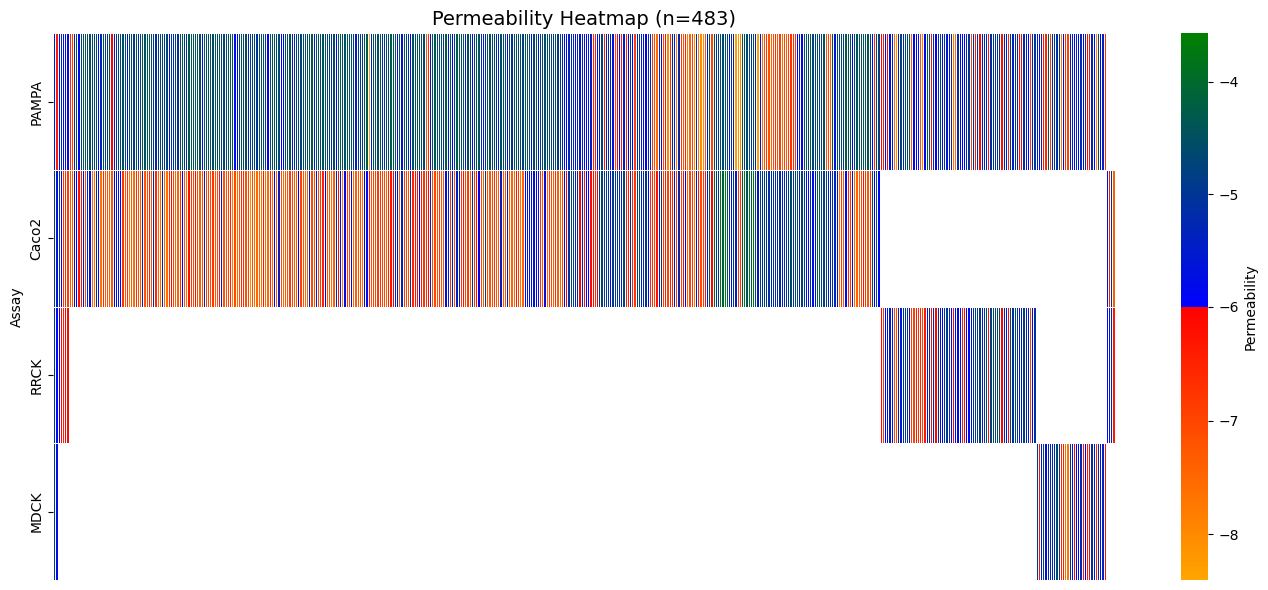

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
assays = ["PAMPA", "Caco2", "RRCK", "MDCK"]

df_heatmap = df_sorted[df_sorted[assays].notna().sum(axis=1) >= 2].copy()

vals = df_heatmap[assays].to_numpy(dtype=float)
data = np.ma.masked_invalid(vals)  

cmap = LinearSegmentedColormap.from_list(
    "redblue_custom",
    [
        (0.0, "orange"),
        (0.5, "red"),
        (0.5, "blue"),
        (1.0, "green"),
    ],
    N=256
)

# Normalize around -6
vmin = np.nanmin(vals)
vmax = np.nanmax(vals)
norm = TwoSlopeNorm(vmin=vmin, vcenter=-6, vmax=vmax)

# Transpose for horizontal orientation
plt.figure(figsize=(14, 6))
ax = sns.heatmap(
    data.T, 
    cmap=cmap,
    norm=norm,
    annot=False,
    linewidths=0.4,
    cbar_kws={"label": "Permeability"},
    xticklabels=False,
    yticklabels=assays 
)

ax.set_title(f"Permeability Heatmap (n={len(df_heatmap)})", fontsize=14)
ax.set_ylabel("Assay")
ax.set_xlabel("")

plt.tight_layout()
plt.savefig("results/Dataset_analysis/multi_filled_heatmap_all_data_assay.png",
            dpi=600, bbox_inches="tight")
plt.show()



In [29]:
import pandas
import numpy as np
df = pd.read_csv('results/Dataset_analysis/sorted_all_data_duplicates_removed_assay_perm_values.csv')
df

,SMILES,PAMPA,Caco2,RRCK,MDCK
0,CC(C)C[C@@H]1NC(=O)[C@H](Cc2ccc(O)cc2)N(C)C(=O...,-5.511429,-4.890,-5.2025,-4.960000
1,CC(C)C[C@@H]1NC(=O)[C@H](Cc2ccc(O)cc2)NC(=O)[C...,-6.386667,-5.545,-5.8050,-5.700000
2,CC[C@H](C)[C@@H]1NC(=O)[C@@H]2CCCN2C(=O)[C@H](...,-5.660000,-5.100,-5.9200,NaN
3,CC[C@H](C)[C@@H]1NC(=O)[C@@H]2CCCN2C(=O)[C@H](...,-5.280000,-5.890,-6.1500,NaN
4,CC(C)C[C@@H]1NC(=O)[C@@H](CC(C)C)NC(=O)[C@@H](...,-5.640000,-6.640,-6.4400,NaN
...,...,...,...,...,...
7961,CCOC(=O)[C@@H]1CSCC(=O)N[C@@H](CC)C(=O)N(CC(C)...,NaN,NaN,NaN,-7.534591
7962,CC(=O)N1CCC[C@@H]1C(=O)N(C)[C@@H](CC(C)C)C(=O)...,NaN,NaN,NaN,-6.300000
7963,CC(C)C[C@@H]1NC(=O)[C@H](C)N(C)C(=O)[C@@H](C)N...,NaN,NaN,NaN,-5.180000
7964,CC[C@H](C)[C@@H]1NC(=O)[C@@H](CC(C)C)NC(=O)[C@...,NaN,NaN,NaN,-4.400000


In [30]:
assays = ["PAMPA", "Caco2", "RRCK", "MDCK"]
corr_matrix = pd.DataFrame(np.nan, index=assays, columns=assays)

for a1 in assays:
    for a2 in assays:
        if a1 == a2:
            corr_matrix.loc[a1, a2] = 1.0
        else:
            subset = df[[a1, a2]].dropna()
            if not subset.empty:
                corr_matrix.loc[a1, a2] = subset[a1].corr(subset[a2])

print(corr_matrix)

          PAMPA     Caco2      RRCK     MDCK
PAMPA  1.000000 -0.160120  0.655446  0.59233
Caco2 -0.160120  1.000000  0.776309  1.00000
RRCK   0.655446  0.776309  1.000000  1.00000
MDCK   0.592330  1.000000  1.000000  1.00000


In [31]:
corr_matrix.to_csv("results/Dataset_analysis/Permeability_assay_correlation_matrix.csv")

In [ ]:
#Inter-Dataset Performance analysis

In [64]:
#Dataset performances on MDCK model
import os
import joblib 

In [66]:
#PAMPA test set
models_dir = '/home/users/akshay/PCPpred/MDCK/models_MDCK' 
scaler_path = '/home/users/akshay/PCPpred/MDCK/models_MDCK/scaler_morgan_fp_mdck.joblib' 
model_base_name = 'GradientBoostingRegressor'                   
n_folds = 5                                    


df_new_test = pd.read_csv('/home/users/akshay/PCPpred/PAMPA/features/Fingerprints/Test/morgan_fp_test.csv')

X_new_test_features = df_new_test.drop(columns=['ID', 'SMILES','Permeability'], errors='ignore')
y_test = df_new_test['Permeability']

scaler = joblib.load(scaler_path)
X_new_scaled = scaler.transform(X_new_test_features)
X_new_scaled = pd.DataFrame(X_new_scaled, columns=X_new_test_features.columns,index=X_new_test_features.index)

all_fold_preds = []

for fold in range(1, n_folds + 1):
    fold_model_path = os.path.join(models_dir, f"{model_base_name}_fold{fold}_mdck.joblib")
    fold_model = joblib.load(fold_model_path)
    preds = fold_model.predict(X_new_scaled)
    preds = np.clip(preds, -10, -4.0)  
    all_fold_preds.append(preds)


all_fold_preds = np.array(all_fold_preds)
mean_prediction = np.mean(all_fold_preds, axis=0)

mse_test = mean_squared_error(y_test, mean_prediction)
print(f"{mse_test:.4f}")
mae_test = mean_absolute_error(y_test, mean_prediction)
print(f"{mae_test:.4f}")
rmse_test = np.sqrt(mse_test)
print(f"{rmse_test:.4f}")
r2_test = r2_score(y_test, mean_prediction)
print(f"{r2_test:.4f}")
pearson_test, _ = pearsonr(y_test, mean_prediction)
print(f"{pearson_test:.4f}")
spearman_test, _ = spearmanr(y_test, mean_prediction)
print(f"{spearman_test:.4f}")

# df_new_test['Predicted_Permeability'] = mean_prediction
# df_new_test.to_csv('path_to_save_predictions.csv', index=False)

print("Prediction on new data complete.")


0.9215
0.7516
0.9599
-0.4494
0.2509
0.2388
Prediction on new data complete.


In [68]:
#Caco-2 test set
models_dir = '/home/users/akshay/PCPpred/MDCK/models_MDCK' 
scaler_path = '/home/users/akshay/PCPpred/MDCK/models_MDCK/scaler_morgan_fp_mdck.joblib' 
model_base_name = 'GradientBoostingRegressor'                   
n_folds = 5                                    


df_new_test = pd.read_csv('/home/users/akshay/PCPpred/Caco2/features/Fingerprints/Test/morgan_fp_test_Caco2.csv')

X_new_test_features = df_new_test.drop(columns=['ID', 'SMILES','Permeability'], errors='ignore')
y_test = df_new_test['Permeability']

scaler = joblib.load(scaler_path)
X_new_scaled = scaler.transform(X_new_test_features)
X_new_scaled = pd.DataFrame(X_new_scaled, columns=X_new_test_features.columns,index=X_new_test_features.index)

all_fold_preds = []

for fold in range(1, n_folds + 1):
    fold_model_path = os.path.join(models_dir, f"{model_base_name}_fold{fold}_mdck.joblib")
    fold_model = joblib.load(fold_model_path)
    preds = fold_model.predict(X_new_scaled)
    preds = np.clip(preds, -10, -4.0)  
    all_fold_preds.append(preds)


all_fold_preds = np.array(all_fold_preds)
mean_prediction = np.mean(all_fold_preds, axis=0)

mse_test = mean_squared_error(y_test, mean_prediction)
print(f"{mse_test:.4f}")
mae_test = mean_absolute_error(y_test, mean_prediction)
print(f"{mae_test:.4f}")
rmse_test = np.sqrt(mse_test)
print(f"{rmse_test:.4f}")
r2_test = r2_score(y_test, mean_prediction)
print(f"{r2_test:.4f}")
pearson_test, _ = pearsonr(y_test, mean_prediction)
print(f"{pearson_test:.4f}")
spearman_test, _ = spearmanr(y_test, mean_prediction)
print(f"{spearman_test:.4f}")


print("Prediction on new data complete.")


1.6664
1.0897
1.2909
-1.4927
-0.1881
-0.0965
Prediction on new data complete.


In [69]:
#RRCK test set
models_dir = '/home/users/akshay/PCPpred/MDCK/models_MDCK' 
scaler_path = '/home/users/akshay/PCPpred/MDCK/models_MDCK/scaler_morgan_fp_mdck.joblib' 
model_base_name = 'GradientBoostingRegressor'                   
n_folds = 5                                    


df_new_test = pd.read_csv('/home/users/akshay/PCPpred/RRCK/features/Fingerprints/Test/morgan_fp_test_RRCK.csv')

X_new_test_features = df_new_test.drop(columns=['ID', 'SMILES','Permeability'], errors='ignore')
y_test = df_new_test['Permeability']

scaler = joblib.load(scaler_path)
X_new_scaled = scaler.transform(X_new_test_features)
X_new_scaled = pd.DataFrame(X_new_scaled, columns=X_new_test_features.columns,index=X_new_test_features.index)

all_fold_preds = []

for fold in range(1, n_folds + 1):
    fold_model_path = os.path.join(models_dir, f"{model_base_name}_fold{fold}_mdck.joblib")
    fold_model = joblib.load(fold_model_path)
    preds = fold_model.predict(X_new_scaled)
    preds = np.clip(preds, -10, -4.0)  
    all_fold_preds.append(preds)


all_fold_preds = np.array(all_fold_preds)
mean_prediction = np.mean(all_fold_preds, axis=0)

mse_test = mean_squared_error(y_test, mean_prediction)
print(f"{mse_test:.4f}")
mae_test = mean_absolute_error(y_test, mean_prediction)
print(f"{mae_test:.4f}")
rmse_test = np.sqrt(mse_test)
print(f"{rmse_test:.4f}")
r2_test = r2_score(y_test, mean_prediction)
print(f"{r2_test:.4f}")
pearson_test, _ = pearsonr(y_test, mean_prediction)
print(f"{pearson_test:.4f}")
spearman_test, _ = spearmanr(y_test, mean_prediction)
print(f"{spearman_test:.4f}")


print("Prediction on new data complete.")


0.8358
0.7650
0.9142
-1.0032
0.0388
0.1988
Prediction on new data complete.


In [ ]:
#Dataset performance on RRCK model KlekotaRoth count

In [92]:
#Caco2 test set
models_dir = '/home/users/akshay/PCPpred/RRCK/models_rrck_KR' 
scaler_path = '/home/users/akshay/PCPpred/RRCK/models_rrck_KR/scaler_rrck_kr.joblib'
                      
model_base_name = 'XGBRegressor'                   
n_folds = 5                                    

df_new_test = pd.read_csv('/home/users/akshay/PCPpred/Caco2/features/Fingerprints/Test/KlekotaRothCount_test_Caco2.csv')

X_new_test_features = df_new_test.drop(columns=['ID', 'SMILES','Permeability'], errors='ignore')
y_test = df_new_test['Permeability']

scaler = joblib.load(scaler_path)
X_new_scaled = scaler.transform(X_new_test_features)
X_new_scaled = pd.DataFrame(X_new_scaled, columns=X_new_test_features.columns,index=X_new_test_features.index)

all_fold_preds = []

for fold in range(1, n_folds + 1):
    fold_model_path = os.path.join(models_dir, f"{model_base_name}_fold{fold}_RRCK.joblib")
    fold_model = joblib.load(fold_model_path)
    preds = fold_model.predict(X_new_scaled)
    preds = np.clip(preds, -10, -4.0)  
    all_fold_preds.append(preds)


all_fold_preds = np.array(all_fold_preds)
mean_prediction = np.mean(all_fold_preds, axis=0)

mse_test = mean_squared_error(y_test, mean_prediction)
print(f"{mse_test:.4f}")
mae_test = mean_absolute_error(y_test, mean_prediction)
print(f"{mae_test:.4f}")
rmse_test = np.sqrt(mse_test)
print(f"{rmse_test:.4f}")
r2_test = r2_score(y_test, mean_prediction)
print(f"{r2_test:.4f}")
pearson_test, _ = pearsonr(y_test, mean_prediction)
print(f"{pearson_test:.4f}")
spearman_test, _ = spearmanr(y_test, mean_prediction)
print(f"{spearman_test:.4f}")

print("Prediction on new data complete.")


0.8580
0.7307
0.9263
-0.2834
0.0938
0.1724
Prediction on new data complete.


In [93]:
#PAMPA test set
models_dir = '/home/users/akshay/PCPpred/RRCK/models_rrck_KR' 
scaler_path = '/home/users/akshay/PCPpred/RRCK/models_rrck_KR/scaler_rrck_kr.joblib'
                      
model_base_name = 'XGBRegressor'                   
n_folds = 5                                    

df_new_test = pd.read_csv('/home/users/akshay/PCPpred/PAMPA/features/Fingerprints/Test/KlekotaRothCount_test.csv')

X_new_test_features = df_new_test.drop(columns=['ID', 'SMILES','Permeability'], errors='ignore')
y_test = df_new_test['Permeability']

scaler = joblib.load(scaler_path)
X_new_scaled = scaler.transform(X_new_test_features)
X_new_scaled = pd.DataFrame(X_new_scaled, columns=X_new_test_features.columns,index=X_new_test_features.index)

all_fold_preds = []

for fold in range(1, n_folds + 1):
    fold_model_path = os.path.join(models_dir, f"{model_base_name}_fold{fold}_RRCK.joblib")
    fold_model = joblib.load(fold_model_path)
    preds = fold_model.predict(X_new_scaled)
    preds = np.clip(preds, -10, -4.0)  
    all_fold_preds.append(preds)


all_fold_preds = np.array(all_fold_preds)
mean_prediction = np.mean(all_fold_preds, axis=0)

mse_test = mean_squared_error(y_test, mean_prediction)
print(f"{mse_test:.4f}")
mae_test = mean_absolute_error(y_test, mean_prediction)
print(f"{mae_test:.4f}")
rmse_test = np.sqrt(mse_test)
print(f"{rmse_test:.4f}")
r2_test = r2_score(y_test, mean_prediction)
print(f"{r2_test:.4f}")
pearson_test, _ = pearsonr(y_test, mean_prediction)
print(f"{pearson_test:.4f}")
spearman_test, _ = spearmanr(y_test, mean_prediction)
print(f"{spearman_test:.4f}")

print("Prediction on new data complete.")


0.6929
0.6378
0.8324
-0.0899
0.2181
0.2081
Prediction on new data complete.


In [94]:
#MDCK test set
models_dir = '/home/users/akshay/PCPpred/RRCK/models_rrck_KR' 
scaler_path = '/home/users/akshay/PCPpred/RRCK/models_rrck_KR/scaler_rrck_kr.joblib'
                      
model_base_name = 'XGBRegressor'                   
n_folds = 5                                    

df_new_test = pd.read_csv('/home/users/akshay/PCPpred/MDCK/features/Fingerprints/Test/KlekotaRothCount_test_MDCK.csv')

X_new_test_features = df_new_test.drop(columns=['ID', 'SMILES','Permeability'], errors='ignore')
y_test = df_new_test['Permeability']

scaler = joblib.load(scaler_path)
X_new_scaled = scaler.transform(X_new_test_features)
X_new_scaled = pd.DataFrame(X_new_scaled, columns=X_new_test_features.columns,index=X_new_test_features.index)

all_fold_preds = []

for fold in range(1, n_folds + 1):
    fold_model_path = os.path.join(models_dir, f"{model_base_name}_fold{fold}_RRCK.joblib")
    fold_model = joblib.load(fold_model_path)
    preds = fold_model.predict(X_new_scaled)
    preds = np.clip(preds, -10, -4.0)  
    all_fold_preds.append(preds)


all_fold_preds = np.array(all_fold_preds)
mean_prediction = np.mean(all_fold_preds, axis=0)

mse_test = mean_squared_error(y_test, mean_prediction)
print(f"{mse_test:.4f}")
mae_test = mean_absolute_error(y_test, mean_prediction)
print(f"{mae_test:.4f}")
rmse_test = np.sqrt(mse_test)
print(f"{rmse_test:.4f}")
r2_test = r2_score(y_test, mean_prediction)
print(f"{r2_test:.4f}")
pearson_test, _ = pearsonr(y_test, mean_prediction)
print(f"{pearson_test:.4f}")
spearman_test, _ = spearmanr(y_test, mean_prediction)
print(f"{spearman_test:.4f}")

print("Prediction on new data complete.")


0.6634
0.6129
0.8145
0.0723
0.4334
0.6703
Prediction on new data complete.


In [ ]:
#Dataset performance of Caco2 fingerprints model

In [95]:
#PAMPA test set
models_dir = '/home/users/akshay/PCPpred/Caco2/models_Caco2_all_fp' 
scaler_path = '/home/users/akshay/PCPpred/Caco2/models_Caco2_all_fp/scaler_caco2.joblib' 
features_path =   '/home/users/akshay/PCPpred/Caco2/models_Caco2_all_fp/fingerprints.joblib'                         
model_base_name = 'XGBRegressor'                   
n_folds = 5                                    
fingerprints = joblib.load('/home/users/akshay/PCPpred/Caco2/models_Caco2_all_fp/fingerprints.joblib')

df_new_test = pd.read_csv('/home/users/akshay/PCPpred/PAMPA/features/Fingerprints/Test/All_fingerprints_test.csv')
X_new_test_features = df_new_test[fingerprints]
y_test = df_new_test['Permeability']

scaler = joblib.load(scaler_path)
X_new_scaled = scaler.transform(X_new_test_features)
X_new_scaled = pd.DataFrame(X_new_scaled, columns=X_new_test_features.columns,index=X_new_test_features.index)

all_fold_preds = []

for fold in range(1, n_folds + 1):
    fold_model_path = os.path.join(models_dir, f"{model_base_name}_fold{fold}_Caco2.joblib")
    fold_model = joblib.load(fold_model_path)
    preds = fold_model.predict(X_new_scaled)
    preds = np.clip(preds, -10, -4.0)  
    all_fold_preds.append(preds)


all_fold_preds = np.array(all_fold_preds)
mean_prediction = np.mean(all_fold_preds, axis=0)

mse_test = mean_squared_error(y_test, mean_prediction)
print(f"{mse_test:.4f}")
mae_test = mean_absolute_error(y_test, mean_prediction)
print(f"{mae_test:.4f}")
rmse_test = np.sqrt(mse_test)
print(f"{rmse_test:.4f}")
r2_test = r2_score(y_test, mean_prediction)
print(f"{r2_test:.4f}")
pearson_test, _ = pearsonr(y_test, mean_prediction)
print(f"{pearson_test:.4f}")
spearman_test, _ = spearmanr(y_test, mean_prediction)
print(f"{spearman_test:.4f}")

print("Prediction on new data complete.")


0.9573
0.7232
0.9784
-0.5058
-0.0733
-0.0009
Prediction on new data complete.


In [96]:
#RRCK test set
models_dir = '/home/users/akshay/PCPpred/Caco2/models_Caco2_all_fp' 
scaler_path = '/home/users/akshay/PCPpred/Caco2/models_Caco2_all_fp/scaler_caco2.joblib' 
features_path =   '/home/users/akshay/PCPpred/Caco2/models_Caco2_all_fp/fingerprints.joblib'                         
model_base_name = 'XGBRegressor'                   
n_folds = 5                                    
fingerprints = joblib.load('/home/users/akshay/PCPpred/Caco2/models_Caco2_all_fp/fingerprints.joblib')

df_new_test = pd.read_csv('/home/users/akshay/PCPpred/RRCK/features/Fingerprints/Test/All_fingerprints_test_RRCK.csv')
X_new_test_features = df_new_test[fingerprints]
y_test = df_new_test['Permeability']

scaler = joblib.load(scaler_path)
X_new_scaled = scaler.transform(X_new_test_features)
X_new_scaled = pd.DataFrame(X_new_scaled, columns=X_new_test_features.columns,index=X_new_test_features.index)

all_fold_preds = []

for fold in range(1, n_folds + 1):
    fold_model_path = os.path.join(models_dir, f"{model_base_name}_fold{fold}_Caco2.joblib")
    fold_model = joblib.load(fold_model_path)
    preds = fold_model.predict(X_new_scaled)
    preds = np.clip(preds, -10, -4.0)  
    all_fold_preds.append(preds)


all_fold_preds = np.array(all_fold_preds)
mean_prediction = np.mean(all_fold_preds, axis=0)

mse_test = mean_squared_error(y_test, mean_prediction)
print(f"{mse_test:.4f}")
mae_test = mean_absolute_error(y_test, mean_prediction)
print(f"{mae_test:.4f}")
rmse_test = np.sqrt(mse_test)
print(f"{rmse_test:.4f}")
r2_test = r2_score(y_test, mean_prediction)
print(f"{r2_test:.4f}")
pearson_test, _ = pearsonr(y_test, mean_prediction)
print(f"{pearson_test:.4f}")
spearman_test, _ = spearmanr(y_test, mean_prediction)
print(f"{spearman_test:.4f}")

print("Prediction on new data complete.")


0.4565
0.5603
0.6756
-0.0940
0.2173
0.2303
Prediction on new data complete.


In [97]:
#MDCK test set
models_dir = '/home/users/akshay/PCPpred/Caco2/models_Caco2_all_fp' 
scaler_path = '/home/users/akshay/PCPpred/Caco2/models_Caco2_all_fp/scaler_caco2.joblib' 
features_path =   '/home/users/akshay/PCPpred/Caco2/models_Caco2_all_fp/fingerprints.joblib'                         
model_base_name = 'XGBRegressor'                   
n_folds = 5                                    
fingerprints = joblib.load('/home/users/akshay/PCPpred/Caco2/models_Caco2_all_fp/fingerprints.joblib')

df_new_test = pd.read_csv('/home/users/akshay/PCPpred/MDCK/features/Fingerprints/Test/All_fingerprints_test_MDCK.csv')
X_new_test_features = df_new_test[fingerprints]
y_test = df_new_test['Permeability']

scaler = joblib.load(scaler_path)
X_new_scaled = scaler.transform(X_new_test_features)
X_new_scaled = pd.DataFrame(X_new_scaled, columns=X_new_test_features.columns,index=X_new_test_features.index)

all_fold_preds = []

for fold in range(1, n_folds + 1):
    fold_model_path = os.path.join(models_dir, f"{model_base_name}_fold{fold}_Caco2.joblib")
    fold_model = joblib.load(fold_model_path)
    preds = fold_model.predict(X_new_scaled)
    preds = np.clip(preds, -10, -4.0)  
    all_fold_preds.append(preds)


all_fold_preds = np.array(all_fold_preds)
mean_prediction = np.mean(all_fold_preds, axis=0)

mse_test = mean_squared_error(y_test, mean_prediction)
print(f"{mse_test:.4f}")
mae_test = mean_absolute_error(y_test, mean_prediction)
print(f"{mae_test:.4f}")
rmse_test = np.sqrt(mse_test)
print(f"{rmse_test:.4f}")
r2_test = r2_score(y_test, mean_prediction)
print(f"{r2_test:.4f}")
pearson_test, _ = pearsonr(y_test, mean_prediction)
print(f"{pearson_test:.4f}")
spearman_test, _ = spearmanr(y_test, mean_prediction)
print(f"{spearman_test:.4f}")

print("Prediction on new data complete.")


0.8167
0.7885
0.9037
-0.1420
-0.0414
0.2287
Prediction on new data complete.


In [82]:
desc_col = joblib.load('/home/users/akshay/PCPpred/PAMPA/pampa_models/selected_features_descriptors.joblib')
fp_col = joblib.load('/home/users/akshay/PCPpred/PAMPA/pampa_models/selected_features_fingerprints.joblib')
emb_col = joblib.load('/home/users/akshay/PCPpred/PAMPA/pampa_models/selected_features_embeddings.joblib')
atomic_col = joblib.load('/home/users/akshay/PCPpred/PAMPA/pampa_models/selected_features_atomic.joblib')

In [83]:
desc_col

['MinEStateIndex',
 'qed',
 'SPS',
 'FpDensityMorgan1',
 'BCUT2D_MWHI',
 'AvgIpc',
 'BalabanJ_x',
 'Ipc',
 'EState_VSA11',
 'VSA_EState10',
 'fr_Al_OH',
 'fr_Ar_N',
 'fr_Ndealkylation2',
 'fr_alkyl_halide',
 'fr_allylic_oxid',
 'fr_aryl_methyl',
 'fr_ester',
 'fr_methoxy',
 'fr_morpholine',
 'fr_para_hydroxylation',
 'fr_piperdine',
 'fr_priamide',
 'fr_unbrch_alkane',
 'AdjacencyMatrix.6',
 'AdjacencyMatrix.9',
 'AdjacencyMatrix.11',
 'AATS',
 'AATS.3',
 'AATS.4',
 'AATS.10',
 'AATS.18',
 'AATS.23',
 'AATS.24',
 'AATS.26',
 'AATS.27',
 'AATS.28',
 'AATS.32',
 'AATS.33',
 'AATS.34',
 'AATS.40',
 'AATS.48',
 'AATS.96',
 'AATS.97',
 'ATSC.2',
 'ATSC.5',
 'ATSC.7',
 'ATSC.8',
 'ATSC.12',
 'ATSC.13',
 'ATSC.14',
 'ATSC.15',
 'ATSC.16',
 'ATSC.17',
 'ATSC.20',
 'ATSC.21',
 'ATSC.22',
 'ATSC.23',
 'ATSC.24',
 'ATSC.25',
 'ATSC.26',
 'ATSC.29',
 'ATSC.30',
 'ATSC.32',
 'ATSC.37',
 'ATSC.44',
 'ATSC.50',
 'ATSC.73',
 'ATSC.76',
 'ATSC.80',
 'ATSC.84',
 'ATSC.92',
 'ATSC.105',
 'ATSC.106',
 'AA

In [90]:
df = pd.read_csv('/home/users/akshay/PCPpred/MDCK/features/Descriptors/Train_2d_3d_all_descriptors_MDCK.csv')


dtype_info = {col: df[col].dtype if col in df.columns else "Not in DataFrame" for col in desc_col}

print("Column dtypes:")
for col, dt in dtype_info.items():
    print(f"{col}: {dt}")

non_numeric = [col for col in cols if col in df.columns and not pd.api.types.is_numeric_dtype(df[col])]

if non_numeric:
    print("\n⚠️ Non-numeric columns found:")
    print(non_numeric)
else:
    print("\n✅ All columns are numeric")


Column dtypes:
MinEStateIndex: float64
qed: float64
SPS: float64
FpDensityMorgan1: float64
BCUT2D_MWHI: float64
AvgIpc: float64
BalabanJ_x: float64
Ipc: float64
EState_VSA11: float64
VSA_EState10: float64
fr_Al_OH: int64
fr_Ar_N: int64
fr_Ndealkylation2: int64
fr_alkyl_halide: int64
fr_allylic_oxid: int64
fr_aryl_methyl: int64
fr_ester: int64
fr_methoxy: int64
fr_morpholine: int64
fr_para_hydroxylation: int64
fr_piperdine: int64
fr_priamide: int64
fr_unbrch_alkane: int64
AdjacencyMatrix.6: float64
AdjacencyMatrix.9: float64
AdjacencyMatrix.11: float64
AATS: float64
AATS.3: float64
AATS.4: float64
AATS.10: float64
AATS.18: float64
AATS.23: float64
AATS.24: float64
AATS.26: float64
AATS.27: float64
AATS.28: float64
AATS.32: float64
AATS.33: float64
AATS.34: float64
AATS.40: float64
AATS.48: float64
AATS.96: float64
AATS.97: float64
ATSC.2: float64
ATSC.5: float64
ATSC.7: float64
ATSC.8: float64
ATSC.12: float64
ATSC.13: float64
ATSC.14: float64
ATSC.15: float64
ATSC.16: float64
ATSC.17: 